## Nightly AOS Data Extraction Pipeline

Extract per-exposure AOS data into a single output table for downstream analysis.
Uses `AOSDatabase` from `nightly_report_ts_version` for the core query,
then adds vmodes, per-corner Zernikes, and summary arrays.

**Author:** Guillem Megias-Homar, Craig Lage, Aaron Roodman  
**Date Created:** 2026-03-07  
**Keywords:** Rubin Observatory, AOS, PID Control

**Based on:**
- Data from EFD and ConsDB via nightly_report_ts_version.ipynb

## Change Log

- **2026-03-13:** Added plot functions (plot_standard_report, plot_detailed_report) from
  nightly_report_ts_version.ipynb. Added tqdm to Butler loop. Added zernike_constrained
  per-corner columns (21 Zernikes × 4 corners, microns wavefront via 12-vmode SVD projection).
  Added build_sensitivity_svd() helper. (AR)
- **2026-03-07:** Initial version. (AR)

## Table of Contents

1. [Setup](#Setup)
2. [Analysis Code](#Analysis-Code)
3. [Load Data](#Load-Data)
4. [Results](#Results)
5. [Multi-Night](#Multi-Night)


In [1]:
# Parameters
day_obs = 20260311
seq_min = 0
seq_max = 1500

<a id='Setup' ></a>
## Setup

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import galsim
import numpy as np
import pandas as pd
pd.set_option("future.no_silent_downcasting", True)
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

from astropy.time import Time, TimeDelta
from lsst.obs.lsst import LsstCam
from lsst.summit.utils import (
    ConsDbClient,
    getAirmassSeeingCorrection,
    getBandpassSeeingCorrection,
)
from lsst.summit.utils.efdUtils import (
    getEfdData,
    getMostRecentRowWithDataBefore,
    makeEfdClient,
)

from lsst.ts.xml.tables.m1m3 import *
from lsst.ts.m1m3.utils import *

from lsst.ts.ofc.state_estimator import StateEstimator
from lsst.ts.ofc import OFCData, SensitivityMatrix

from lsst.daf.butler import Butler
from lsst.ts.wep.utils import makeDense

if 'no_proxy' in os.environ:
    os.environ['no_proxy'] += ',.consdb'
else:
    os.environ['no_proxy'] = '.consdb'

%matplotlib inline

<a id="Analysis-Code"></a>
## Analysis Code

Helper functions, the `AOSDatabase` class, and the `build_nightly_table` pipeline.

In [3]:
def getPsfGradPerZernike(
    diameter: float = 8.36,
    obscuration: float = 0.612,
    jmin: int = 4,
    jmax: int = 22,
) -> np.ndarray:
    """Get the gradient of the PSF FWHM with respect to each Zernike."""
    if jmin < 0:
        raise ValueError("jmin cannot be negative.")
    if jmax < jmin:
        raise ValueError("jmax must be greater than jmin.")
    conversion_factors = np.zeros(jmax + 1)
    for i in range(jmin, jmax + 1):
        coefs = [0] * i + [1]
        R_outer = diameter / 2
        R_inner = R_outer * obscuration
        Z = galsim.zernike.Zernike(coefs, R_outer=R_outer, R_inner=R_inner)
        rms_tilt = np.sqrt(np.sum(Z.gradX.coef**2 + Z.gradY.coef**2) / 2)
        rms_tilt = np.rad2deg(rms_tilt * 1e-6) * 3600
        fwhm_tilt = 2 * np.sqrt(2 * np.log(2)) * rms_tilt
        conversion_factors[i] = fwhm_tilt
    return conversion_factors[jmin:]


def convertZernikesToPsfWidth(
    zernikes: np.ndarray,
    diameter: float = 8.36,
    obscuration: float = 0.612,
    jmin: int = 4,
) -> np.ndarray:
    """Convert Zernike amplitudes to quadrature contribution to the PSF FWHM."""
    if jmin < 0:
        raise ValueError("jmin cannot be negative.")
    jmax = jmin + np.array(zernikes).shape[-1] - 1
    conversion_factors = getPsfGradPerZernike(jmin=jmin, jmax=jmax, diameter=diameter, obscuration=obscuration)
    dFWHM = conversion_factors * zernikes
    return dFWHM


async def find_faults(client, table):
    """Find faults during the night."""
    table_time = pd.to_datetime(table["time"], format="ISO8601", utc=True)
    topics = ["MTMount", "MTAOS", "MTHexapod", "MTCamera"]
    table["faults"] = [None for i in range(len(table))]
    start = Time(table["obs_start"].iloc[0], scale="tai").utc
    end = Time(table["obs_end"].iloc[-1], scale="tai").utc
    for topic in topics:
        efd_data = await client.select_time_series(
            f"lsst.sal.{topic}.logevent_summaryState",
            ["summaryState"],
            start, end,
        )
        if len(efd_data) == 0:
            continue
        faults = efd_data[efd_data["summaryState"] == 3]
        for i in range(len(faults)):
            fault_time = pd.to_datetime(faults.index[i], format="utc")
            closest_row = table.iloc[(table_time - fault_time).abs().argmin()]
            table.loc[table["seq"] == closest_row["seq"], "faults"] = topic
    return table


async def get_m1m3_gradients(client, data):
    """Get the M1M3 thermal gradients."""
    date_strings = Time(
        [str(x) for x in data["obs_start"].values], format="isot", scale="tai"
    ).utc.isot
    data_times = pd.to_datetime(date_strings, format="ISO8601", utc=True)
    sorted_data_times = data_times.sort_values()
    start = Time(sorted_data_times[0])
    end = Time(sorted_data_times[-1])
    data_times = data_times.astype("int64")
    thermocouples = ThermocoupleAnalysis(client)
    await thermocouples.load(start, end, time_bin=30)
    gradients = thermocouples.xyz_r_gradients
    grad_times = pd.to_datetime(gradients.index, format="ISO8601", utc=True).astype("int64")
    t0 = grad_times[0]
    grad_times -= t0
    grad_times /= 1E9
    data_times -= t0
    data_times /= 1E9
    names = ["x_gradient", "y_gradient", "z_gradient", "radial_gradient"]
    for name in names:
        values = gradients[name].values
        val_series = pd.Series(values)
        val_interpolated = val_series.interpolate()
        data[name] = np.interp(data_times, grad_times, val_interpolated)
    return data


def build_sensitivity_svd(ofc_data, dof_set_name='standard_22'):
    """Build sensitivity matrix SVD for the given DOF subset.

    Parameters
    ----------
    ofc_data : OFCData
        Configured OFC data object (with dof_idx set).
    dof_set_name : str
        DOF subset name ('standard_22', 'hexapod_10', etc.).

    Returns
    -------
    svd_result : dict
        Keys: U, s, V, dof_indices, norm_vector, A_sub, n_modes
    """
    sensor_name_list = ['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0']

    # Zernike selection: z4-z19, z22-z26 (21 terms, skip z20, z21, z27, z28)
    zn = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
                   22, 23, 24, 25, 26])
    zn_idx = zn - 4

    dof_sets = {
        'hexapod_10': list(range(0, 10)),
        'standard_22': list(range(0, 17)) + list(range(30, 35)),
    }

    field_angles = [ofc_data.sample_points[s] for s in sensor_name_list]
    dz_sensitivity_matrix = SensitivityMatrix(ofc_data)
    sens_3d = dz_sensitivity_matrix.evaluate(field_angles, 0.0)

    # Select Zernike subset, reshape to 2D (all 50 DOFs)
    sens_3d = sens_3d[:, zn_idx, :]
    A_full = sens_3d.reshape((-1, sens_3d.shape[2]))

    # Restrict to chosen DOF subset, then normalize
    dof_indices = dof_sets[dof_set_name]
    A_sub = A_full[:, dof_indices]
    norm_vector = ofc_data.normalization_weights[dof_indices]
    Atilde_sub = A_sub @ np.diag(norm_vector)

    # SVD
    U, s, Vh = np.linalg.svd(Atilde_sub, full_matrices=False)
    V = Vh.T

    return dict(
        U=U, s=s, V=V,
        dof_indices=dof_indices,
        norm_vector=norm_vector,
        A_sub=A_sub,
        n_modes=len(s),
    )

In [4]:
# --- Plot constants ---

band_colors = {
    "u": "#0c71ff", "g": "#49be61", "r": "#c61c00",
    "i": "#ffc200", "z": "#f341a2", "y": "#5d0000",
}

# Zernike aberration groups (indices into zernikes_fwhm, 0-based from Z4)
zk_groups = [[0], [11 - 4], [1, 2], [3, 4], [5, 6], [22]]
zk_group_labels = ['Z4', 'Z11', 'Z5 / Z6', 'Z7 / Z8', ' Z9 / Z10', 'Z22']

# Hexapod DOF groups (indices into first 10 DOFs)
groups = [[0], [5], [1, 2], [6, 7], [3, 4], [8, 9]]
group_labels = [' M2 dz', 'Cam dz', 'M2 dx/dy', 'Cam dx/dy', 'M2 tilts', 'Cam tilts']
labels = ['m2 dz', 'm2 dx', 'm2 dy', 'm2 rx', 'm2 ry',
          'cam dz', 'cam dx', 'cam dy', 'cam rx', 'cam ry']

# Mirror bending mode groups (indices into full 50-DOF state)
mirror_groups = [[10, 11, 30, 31], [12, 34], [13, 14, 32, 33],
                 [15, 16, 35, 36], [17, 18, 37, 38]]
mirror_group_labels = ['Astig', 'Spherical', 'Trefoil', 'Coma', 'Quad']
all_labels = ['M2 dz', 'M2 dx', 'M2 dy', 'M2 rx', 'M2 ry',
     'cam dz', 'cam dx', 'cam dy', 'cam rx', 'cam ry',
     'B1,1', 'B1,2', 'B1,3', 'B1,4', 'B1,5',
     'B1,6', 'B1,7', 'B1,8', 'B1,9', 'B1,10',
     'B1,11', 'B1,12', 'B1,13', 'B1,14', 'B1,15',
     'B1,16', 'B1,17', 'B1,18', 'B1,19', 'B1,20',
     'B2,1', 'B2,2', 'B2,3', 'B2,4', 'B2,5',
     'B2,6', 'B2,7', 'B2,8', 'B2,9', 'B2,10',
     'B2,11', 'B2,12', 'B2,13', 'B2,14', 'B2,15',
     'B2,16', 'B2,17', 'B2,18', 'B2,19', 'B2,20']

vmode_labels = ['Vmode1\nM2 tilts -rx-ry', 'Vmode2\nM2 tilts -rx+ry',
                'Vmode3\nCam tilts -rx+ry', 'Vmode4\nCam tilts rx+ry',
                'Vmode5\nZ4-Focus', 'Vmode6\nZ5-Astig-Oblique',
                'Vmode7\nZ6-Astig-Vert', 'Vmode8\nZ7-Coma-Vert',
                'Vmode9\nZ8-Come-Horiz', 'Vmode10\nZ9-Trefoil-Vert',
                'Vmode11\nZ10-Trefoil-Oblique', 'Vmode12\nZ11-Spherical']


# --- Plot helper functions ---

def annotate_bands(data, ax, bottom_stripes=False):
    """Fill an axis with band-colored stripes."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    maxSeq = np.max(data['seq'].values)
    change_seqs = data.index[data['band'].ne(data['band'].shift())].to_list()
    change_intervals = []
    stripe_colors = []
    for i, seq in enumerate(change_seqs):
        if i == len(change_seqs) - 1:
            break
        change_intervals.append((seq, change_seqs[i + 1] - seq))
        band_name = list(data['band'].loc[seq])[0]
        stripe_colors.append(band_colors[band_name])
    change_intervals.append((change_seqs[-1], maxSeq - change_seqs[-1]))
    band_name = list(data['band'].loc[maxSeq])[0]
    stripe_colors.append(band_colors[band_name])

    if bottom_stripes:
        ax.broken_barh(change_intervals, (ylim[0], 0.08 * (ylim[1] - ylim[0])),
                       facecolors=stripe_colors)
        unique_bands = data['band'].str[0].unique()
        for band_char in sorted(unique_bands):
            ax.scatter([], [], c=band_colors[band_char], s=100, marker='s',
                       label=f'{band_char}')
    else:
        ax.broken_barh(change_intervals, (ylim[0], ylim[1] - ylim[0]),
                       facecolors=stripe_colors, alpha=0.07)


def find_blocks(data):
    """Find blocks active during the night.

    Returns DataFrame with 'seq' and 'block_after' columns.
    """
    block_data = data[['seq', 'block']].copy().reset_index(drop=True).sort_values(by='seq')
    change_mask = block_data['block'] != block_data['block'].shift()
    block_data['block'] = block_data['block'].str.replace('BLOCK-', '', regex=False)
    blocks = pd.DataFrame({
        'seq': block_data.loc[change_mask, 'seq'],
        'block_after': block_data['block'].loc[change_mask]
    })
    return blocks


def plot_m1m3_gradients(data, ax):
    """Plot the M1M3 thermal gradients on the given axis."""
    blues = plt.get_cmap('Blues')
    oranges = plt.get_cmap('Oranges')

    c_x = blues(0.75)
    c_y = blues(0.55)
    c_r = oranges(0.75)
    c_z = oranges(0.55)

    band_xy = blues(0.25)
    band_rz = oranges(0.25)

    ax.axhspan(-0.4, 0.4, facecolor=band_xy, alpha=0.3, zorder=0)
    ax.axhspan(-0.1, 0.1, facecolor=band_rz, alpha=0.3, zorder=0)
    ax.axhline(0.4, color=blues(0.65), linestyle="-", linewidth=1, alpha=0.5)
    ax.axhline(-0.4, color=blues(0.65), linestyle="-", linewidth=1, alpha=0.5)
    ax.axhline(0.1, color=oranges(0.65), linestyle="-", linewidth=1, alpha=0.5)
    ax.axhline(-0.1, color=oranges(0.65), linestyle="-", linewidth=1, alpha=0.5)

    ax.scatter(data['seq'], data['x_gradient'] * 8.4,
               label="X (×8.4)", color=c_x, s=0.5, zorder=3)
    ax.scatter(data['seq'], data['y_gradient'] * 8.4,
               label="Y (×8.4)", color=c_y, s=0.5, zorder=3)
    ax.scatter(data['seq'], data['radial_gradient'] * 3.7,
               label="Radial (×4.2)", color=c_r, s=0.5, zorder=4)
    ax.scatter(data['seq'], data['z_gradient'],
               label="Z", color=c_z, s=0.5, zorder=4)

    data_leg = ax.legend(bbox_to_anchor=(0.0, 1.25), loc='upper left',
                         frameon=True, ncol=2, markerscale=4)
    ax.add_artist(data_leg)

    band_handles = [
        Patch(facecolor=band_xy, alpha=0.6, label="X/Y limit band (±0.4)"),
        Patch(facecolor=band_rz, alpha=0.6, label="Radial/Z limit band (±0.1)"),
    ]
    ax.legend(handles=band_handles, loc="upper right", frameon=True,
              bbox_to_anchor=(1.0, 1.25))

    ax.set_ylim(-1.2, 0.6)
    return

In [5]:
def plot_standard_report(table, day_obs, save_png=False):
    """Standard survey report: PSF metrics, thermal, Zernike aberrations,
    hexapod DOFs, and system contribution scatter plots.

    Parameters
    ----------
    table : DataFrame
        Output of build_nightly_table (seq as both index and column).
    day_obs : int
        Observation day.
    save_png : bool
        If True, save figure to nightly_report_standard_{day_obs}.png.
    """
    if len(table) == 0:
        print("No data to plot")
        return

    # --- Extract data ---
    filtered_table = table
    valid = filtered_table.dropna(subset=["dof_state", "zernikes_fwhm", "lut_state"])
    dof_state = np.vstack(valid["dof_state"].values)
    zernikes_fwhm = np.vstack(valid["zernikes_fwhm"].values)
    lut_state = np.vstack(valid["lut_state"].values)
    seqs = valid.index.values

    # Zernike arcsec-to-micron ratios (clean replacement for raw zernikes hack)
    conversion_factors = getPsfGradPerZernike(jmin=4, jmax=28)
    zernike_ratios = {}
    for id_group, zk_group in enumerate(zk_groups):
        zk_label = zk_group_labels[id_group]
        zernike_ratios[zk_label] = 1.0 / conversion_factors[zk_group[0]]

    # AOS jumps
    aos_diff = filtered_table["aos_fwhm"].diff()
    jump_indices = filtered_table["seq"][aos_diff > 0.3].tolist()

    linewidth = 0.7

    fig = plt.figure(figsize=(31, 18))

    # Top GridSpec (upper half)
    gs_top = gridspec.GridSpec(
        nrows=6, ncols=4,
        width_ratios=[4, 2, 2.15, 2],
        height_ratios=[1]*6,
        hspace=0.0, wspace=0.26,
        top=0.97, bottom=0.54
    )

    # Bottom GridSpec (lower half)
    gs_bot = gridspec.GridSpec(
        nrows=6, ncols=4,
        width_ratios=[4, 2, 2.15, 2],
        height_ratios=[1]*6,
        hspace=0.0, wspace=0.26,
        top=0.46, bottom=0.05
    )

    # -- Left column: Survey performance (top)
    axes = []
    for i in range(6):
        ax = fig.add_subplot(gs_top[i, 0], sharex=axes[0] if i > 0 else None)
        axes.append(ax)
    axes[0].scatter(filtered_table['seq'], filtered_table['fwhm_zenith_500nm'], s=3, label='FWHM_Zenith_500nm')
    axes[0].scatter(filtered_table['seq'], filtered_table['donut_blur_fwhm'], s=3, label='Donut Blur FWHM')
    axes[0].scatter(filtered_table['seq'], filtered_table["psf_fwhm_95_05"], s=3, label="FWHM:sqrt(95^2-5^2)")
    ax0_ell = axes[0].twinx()
    ax0_ell.scatter(filtered_table['seq'], filtered_table["psf_ellipticity_median"], s=3, color='red', label="Ellipticity      ")
    ax0_ell.set_ylim(0, 0.8)
    ax0_ell.set_yticks([0.0, 0.1, 0.2])
    ax0_ell.set_ylabel("Ellipticity")
    ax0_ell.yaxis.set_label_coords(1.02, 0.65)
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = ax0_ell.get_legend_handles_labels()
    axes[0].legend(h1 + h2, l1 + l2, fontsize=8, bbox_to_anchor=(1.0, 1.6),
                   loc='upper right', markerscale=2)

    ymin0 = 0; ymax0 = 2.0
    axes[0].set_ylim(ymin0, ymax0)
    (xmin, xmax) = axes[0].get_xlim()
    axes[0].text(xmin, ymax0 * 1.1, "... Faults", fontsize=14, color='magenta')
    axes[0].set_ylabel('FWHM [arcsec]')
    axes[0].set_title('Delivered Seeing and System Variables')
    axes[1].scatter(filtered_table['seq'], filtered_table["aos_fwhm"], s=3, label='AOS FWHM')
    axes[2].scatter(filtered_table['seq'], filtered_table['elevation'], color='k', s=3)
    axes[3].scatter(filtered_table['seq'], filtered_table['azimuth'], color='k', s=3)
    axes[4].scatter(filtered_table['seq'], filtered_table['rotation_angle'], color='k', s=3)
    max_corr_lag = 10
    corr_lag = filtered_table['seq'] - filtered_table['seq_num_corr']
    corr_lag = np.clip(corr_lag, 0, max_corr_lag)
    axes[5].scatter(filtered_table['seq'], corr_lag, color='k', s=3)
    axes[5].minorticks_on()

    axes[0].set_ylabel('FWHM\n[arcsec]')
    axes[1].set_ylabel('AOS FWHM\n[arcsec]')
    axes[2].set_ylabel('Elevation\n[deg]')
    axes[3].set_ylabel('Azimuth\n[deg]')
    axes[4].set_ylabel('Rotator\n[deg]')
    axes[5].set_ylabel('Correction Lag\n[# of visits]')
    axes[5].set_xlabel('Sequence Number')

    for ax in axes[1::]:
        for x in jump_indices:
            ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
    axes[1].set_ylim(0.25, 1.25)
    axes[1].set_yticks([0.5, 1.0])
    blocks = find_blocks(filtered_table)
    maxSeq = max(filtered_table['seq'].values)
    for i, changeSeq in enumerate(blocks['seq']):
        if i < len(blocks) - 1:
            changeWidth = blocks['seq'].iloc[i+1] - changeSeq
        else:
            changeWidth = maxSeq - changeSeq
        for ax in axes[0::]:
            ax.axvline(changeSeq, ls='--', color='k', linewidth=linewidth, alpha=0.5)
        if changeWidth > 5:
            (ymin1, ymax1) = axes[1].get_ylim()
            ytext = ymin1 + (ymax1 - ymin1) * 0.5
            axes[1].text(int(changeSeq + changeWidth / 2 - 2), ytext,
                         blocks['block_after'].iloc[i], fontsize=8, rotation=90, alpha=0.6)

    faults = filtered_table[filtered_table['faults'].notnull()]
    for k in range(len(faults)):
        for ax in axes[0::]:
            ax.axvline(faults['seq'].iloc[k], color='magenta', ls=':')

    for ax in axes:
        ax.grid(True, alpha=0.5)
        ax.tick_params(direction='in', which='both')
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
    for ax in axes:
        annotate_bands(filtered_table, ax)
    annotate_bands(filtered_table, axes[5], bottom_stripes=True)
    axes[5].legend(ncols=3)

    # -- Left column: Thermal (bottom)
    axes[0] = fig.add_subplot(gs_bot[0:2, 0])
    axes[1] = fig.add_subplot(gs_bot[2:4, 0])
    axes[2] = fig.add_subplot(gs_bot[4:, 0])
    axes = [axes[0], axes[1], axes[2]]
    plot_m1m3_gradients(filtered_table, axes[0])
    min_temp = 1000.0; max_temp = -1000
    for temp in ['cam_air_temp', 'm2_air_temp', 'm1m3_air_temp', 'outside_temp']:
        this_max = np.max(filtered_table[temp])
        this_min = np.min(filtered_table[temp])
        if this_max > max_temp:
            max_temp = this_max
        if this_min < min_temp:
            min_temp = this_min
    axes[1].scatter(filtered_table['seq'], filtered_table['cam_air_temp'], color="C0", s=3, label="ESS:111 camera air Temperature")
    axes[1].scatter(filtered_table['seq'], filtered_table['m2_air_temp'], color="C1", s=3, label="ESS:112 M2 air Temperature")
    axes[1].scatter(filtered_table['seq'], filtered_table['m1m3_air_temp'], color="C2", s=3, label="ESS:113 M1M3 air Temperature")
    axes[1].scatter(filtered_table['seq'], filtered_table['outside_temp'], color="C6", s=3, label="ESS:301 Outside Temperature")
    leg4 = axes[1].legend(loc='upper right', ncols=2, markerscale=2)
    leg4.get_frame().set_linewidth(0)
    leg4.get_frame().set_edgecolor("none")
    leg4.get_frame().set_facecolor("none")
    axes[1].set_ylim(min_temp * 0.95, max_temp * 1.1)

    axes[2].scatter(filtered_table['seq'], filtered_table['m2_delta_t'], color='C0', s=3, label='M2-M1M3')
    axes[2].scatter(filtered_table['seq'], filtered_table['cam_m1m3_delta_t'], color='C1', s=3, label='Cam-M1M3')
    axes[2].scatter(filtered_table['seq'], filtered_table['dome_delta_t'], color='C2', s=3, label='Out-M1M3')
    leg3 = axes[2].legend(loc='upper right', ncols=3, markerscale=2, framealpha=0.5)
    leg3.get_frame().set_linewidth(0)
    leg3.get_frame().set_edgecolor("none")
    leg3.get_frame().set_facecolor("none")

    axes[1].set_ylabel('Temps\n[C]')
    axes[2].set_ylabel('Temp DIffs\n[C]')
    axes[2].set_xlabel('Sequence Number')

    for ax in axes:
        for x in jump_indices:
            ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
    for ax in axes:
        ax.grid(True, alpha=0.5)
        ax.tick_params(direction='in', which='both')
    axes[0].set_title('M1M3 Thermal Gradients', y=1.02)

    # -- Col 1 top: Zernike aberrations
    axes = [fig.add_subplot(gs_top[i, 1]) for i in range(6)]
    for id_group, (ax, zk_group) in enumerate(zip(axes, zk_groups)):
        zk_label = zk_group_labels[id_group]
        for zk_idx, i in enumerate(zk_group):
            vals = zernikes_fwhm[:, i]
            if zk_idx == 0:
                combined_vals = vals
            else:
                combined_vals = np.concatenate((combined_vals, vals))
            ymin = np.percentile(combined_vals, 1)
            ymax = np.percentile(combined_vals, 99)
            if zk_label == 'Z4':
                ymax = min(0.2, ymax)
            if ymin < 0:
                ymin *= 1.25
            else:
                ymin *= 0.75
            if ymax > 0:
                ymax *= 1.25
            else:
                ymax *= 0.75
        ymin_microns = zernike_ratios[zk_label] * ymin
        ymax_microns = zernike_ratios[zk_label] * ymax
        for zk_idx, i in enumerate(zk_group):
            if len(zk_group) == 1:
                zk_sublabel = ''
            if len(zk_group) == 2:
                zk_sublabel = zk_label.split('/')[zk_idx].strip()
            vals = zernikes_fwhm[:, i]
            color = 'blue' if zk_idx == 0 else 'orange' if zk_idx == 1 else None
            clip_vals = np.clip(vals, ymin, ymax)
            ax.scatter(seqs, clip_vals, s=5, color=color, label=zk_sublabel)
        ax.set_ylabel(f"{zk_label}\n[arcsec]")
        if zk_label == 'Z4':
            ax.axhline(-0.15, ls='--', color='green')
        ax.grid(True, alpha=0.5)
        ax.tick_params(direction="in")
        ax.set_ylim(ymin, ymax)
        ax2 = ax.twinx()
        ax2.set_ylim(ymin_microns, ymax_microns)
        ax2.set_ylabel("Microns")
        leg1 = ax.legend(bbox_to_anchor=(0.2, 1.05), loc='upper left',
                         ncol=2, markerscale=2, frameon=False)

    annotate_bands(filtered_table, axes[0])
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
        ax.grid(True, alpha=0.5)
    for ax in axes:
        for x in jump_indices:
            ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
    axes[-1].set_xlabel("Sequence Number")
    axes[0].set_title('Optical Aberrations (average over FOV)')

    # -- Col 1 bottom: Hexapod DOFs
    axes = [fig.add_subplot(gs_bot[i, 1]) for i in range(6)]
    for id_group, (ax, dof_group) in enumerate(zip(axes, groups)):
        for i in dof_group:
            vals = dof_state[:, i]
            ax.scatter(seqs, vals, label=f"{labels[i]}", s=3)
        ax.set_ylabel(group_labels[id_group])
        ax.grid(True, alpha=0.5)
        ax.tick_params(direction="in")
        leg2 = ax.legend(bbox_to_anchor=(1.28, 0.5), loc='center right', markerscale=3)
        leg2.get_frame().set_linewidth(0)
        leg2.get_frame().set_edgecolor("none")
        leg2.get_frame().set_facecolor("none")

    annotate_bands(filtered_table, axes[0])
    annotate_bands(filtered_table, axes[1])
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
        ax.grid(True, alpha=0.5)
    for ax in axes:
        for x in jump_indices:
            ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
    axes[0].set_title('Hexapods State (Trim only)')
    axes[-1].set_xlabel("Sequence Number")

    # -- Cols 2-3: System contribution scatter plots
    ax1 = fig.add_subplot(gs_top[3:, 2])
    ax0 = fig.add_subplot(gs_top[:3, 2], sharex=ax1)
    ax3 = fig.add_subplot(gs_bot[3:, 2])
    ax2 = fig.add_subplot(gs_bot[:3, 2], sharex=ax3)
    ax5 = fig.add_subplot(gs_bot[3:, 3])
    ax4 = fig.add_subplot(gs_bot[:3, 3], sharex=ax5)
    axes = [ax0, ax1, ax2, ax3, ax4, ax5]

    axes[0].set_xlim(0.5, 2.0)
    axes[0].set_ylim(0.5, 2.0)
    axes[0].set_ylabel("Donut blur [arcsec]")
    axes[0].set_title("Image Quality Metrics")
    axes[0].set_aspect(1.0)
    axes[0].tick_params(labelbottom=False)
    axes[0].grid(alpha=0.2)
    xs = np.linspace(0.5, 2.0, 100)
    ys = np.sqrt(xs**2 - 0.40**2)
    axes[0].plot(xs, xs, ls='--', color='red')
    axes[0].plot(xs, ys, ls='--', color='green')
    axes[0].text(0.1, 0.9, 'FWHM=Blur',
                 horizontalalignment='left', verticalalignment='center',
                 transform=axes[0].transAxes, color='red')
    axes[0].text(0.1, 0.85, 'FWHM=sqrt(Blur**2 + 0.4**2)',
                 horizontalalignment='left', verticalalignment='center',
                 transform=axes[0].transAxes, color='green')

    donut_blur = filtered_table['donut_blur_fwhm'].values
    ax0_histy = axes[0].inset_axes([1.0, 0, 0.5, 1], sharey=axes[0])
    ax0_histy.hist(donut_blur, bins=20, histtype='step', range=(0.5, 2.0), lw=2, orientation='horizontal')
    ax0_histy.yaxis.tick_right()
    ax0_histy.set_xticks([])
    ax0_histy.set_xticklabels([])
    ax0_histy.grid(alpha=0.2)
    ax0_histy.text(0.5, 0.8, f'Median = {np.nanmedian(donut_blur):.2f}"',
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax0_histy.transAxes)

    fwhm = filtered_table['psf_fwhm'].values
    ax0_histx = axes[0].inset_axes([0, 1.0, 1, 0.25], sharex=axes[0])
    ax0_histx.hist(fwhm, bins=20, histtype='step', lw=2, orientation='vertical')
    ax0_histx.grid(alpha=0.2)
    ax0_histx.text(0.8, 0.8, f'Median = {np.nanmedian(fwhm):.2f}"',
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax0_histx.transAxes)

    x = filtered_table["psf_fwhm"].values
    y = filtered_table["psf_ellipticity_median"].values
    xerr = filtered_table["psf_fwhm_sigma"].values
    yerr = filtered_table["psf_ellipticity_sigma"].values
    for band in band_colors.keys():
        band_table = filtered_table[filtered_table['band'].str[0] == band]
        axes[0].scatter(band_table['psf_fwhm'], band_table['donut_blur_fwhm'],
                        s=8, color=band_colors[band])
        x_band = band_table["psf_fwhm"].values
        y_band = band_table["psf_ellipticity_median"].values
        xerr_band = band_table["psf_fwhm_sigma"].values
        yerr_band = band_table["psf_ellipticity_sigma"].values
        axes[1].errorbar(x_band, y_band, xerr=xerr_band, yerr=yerr_band,
                         fmt='o', markersize=3, elinewidth=0.1, capsize=1,
                         color=band_colors[band], alpha=0.7)
    axes[1].set_ylabel("Ellipticity")
    axes[1].set_xlabel("FWHM [arcsec]")
    axes[1].set_xticks([0.6, 1.0, 1.4, 1.8, 2.0])
    axes[1].set_box_aspect(1.0)
    axes[1].grid(alpha=0.2)

    ax1_histy = axes[1].inset_axes([1.0, 0, 0.5, 1], sharey=axes[1])
    ax1_histy.hist(y, bins=20, histtype='step', lw=2, orientation='horizontal')
    ax1_histy.yaxis.tick_right()
    ax1_histy.grid(alpha=0.2)
    ax1_histy.text(0.5, 0.8, f'Median = {np.nanmedian(y):.3f}"',
                   horizontalalignment='center', verticalalignment='center',
                   transform=ax1_histy.transAxes)

    camera_contrib = 0.207
    sys_3 = np.sqrt(filtered_table["psf_fwhm"].values**2 - (filtered_table["donut_blur_fwhm"].values**2 - camera_contrib**2))
    y = filtered_table["psf_ellipticity_median"].values
    in_spec = [[a, b] for a, b in zip(sys_3, y) if (a < 0.45) and (b < 0.1)]
    pass_2 = f"\n{(len(in_spec) / len(sys_3) * 100.0):.1f}% in green region"
    axes[2].scatter(sys_3, y, s=4, color='tab:orange')
    axes[2].set_ylabel("Ellipticity")
    axes[2].set_box_aspect(1.0)
    axes[2].tick_params(labelbottom=False)
    axes[2].grid(alpha=0.2)
    axes[2].set_title("System Contribution Metrics")
    axes[2].set_ylim(top=0.5)

    x = filtered_table["psf_fwhm_95_05"]
    y = filtered_table["psf_ellipticity_median"].values
    in_spec = [[a, b] for a, b in zip(x, y) if (a < 0.45) and (b < 0.1)]
    pass_3 = f"\n{(len(in_spec) / len(x) * 100.0):.1f}% in green region"
    axes[3].scatter(x, y, s=4, color='tab:red')
    axes[3].set_ylabel("Ellipticity")
    axes[3].set_xlabel("[arcsec]")
    axes[3].set_box_aspect(1.0)
    axes[3].grid(alpha=0.2)
    axes[3].set_ylim(top=0.5)

    sys_2 = np.sqrt(filtered_table["aos_fwhm"].values**2 + camera_contrib**2)
    axes[4].hist(sys_2, bins=30, range=(0.0, 1.0), histtype='step', lw=2, color='tab:blue', label='sqrt(AOS^2+Cam^2)')
    axes[4].hist(sys_3, bins=30, range=(0.0, 1.0), histtype='step', lw=2, color='tab:orange', label='sqrt(FWHM^2-(Blur^2-Cam^2))')
    axes[4].hist(filtered_table["psf_fwhm_95_05"], bins=30, range=(0.0, 1.0), histtype='step', lw=2, color='tab:red', label='FWHM:sqrt(95^2-5^2)')
    axes[4].set_xlim(0.0, 1.0)
    axes[4].set_box_aspect(1.0)
    axes[4].tick_params(labelbottom=False)
    axes[4].axvline(0.45, ls='--', color='black', alpha=0.5)
    axes[4].text(0.2, 0.90, f'Median = {np.nanmedian(sys_2):.2f}"',
                 horizontalalignment='center', verticalalignment='center',
                 transform=axes[4].transAxes, color='tab:blue')
    axes[4].text(0.2, 0.85, f'Median = {np.nanmedian(sys_3):.2f}"',
                 horizontalalignment='center', verticalalignment='center',
                 transform=axes[4].transAxes, color='tab:orange')
    axes[4].text(0.2, 0.80, f'Median = {np.nanmedian(filtered_table["psf_fwhm_95_05"].values):.2f}"',
                 horizontalalignment='center', verticalalignment='center',
                 transform=axes[4].transAxes, color='tab:red')

    legend_patches = [
        Patch(facecolor='tab:blue', edgecolor='none', label='sqrt(AOS^2 + Cam^2)'),
        Patch(facecolor='tab:orange', edgecolor='none', label='sqrt(FWHM^2 - (Blur^2 - Cam^2))'),
        Patch(facecolor='tab:red', edgecolor='none', label='FWHM: sqrt(95^2 - 5^2)'),
    ]
    axes[4].legend(handles=legend_patches, loc='upper center',
                   bbox_to_anchor=(0.4, 1.2), frameon=False, borderaxespad=0.)
    shift = -0.035
    pos = axes[4].get_position()
    axes[4].set_position([pos.x0 + shift, pos.y0, pos.width, pos.height])
    axes[4].grid(alpha=0.2)

    x = sys_2
    y = filtered_table["psf_ellipticity_median"].values
    in_spec = [[a, b] for a, b in zip(x, y) if (a < 0.45) and (b < 0.1)]
    pass_5 = f"\n{(len(in_spec) / len(x) * 100.0):.1f}% in green region"
    axes[5].scatter(x, y, s=4, color='tab:blue')
    axes[5].set_xlabel("[arcsec]")
    axes[5].set_box_aspect(1.0)
    shift = -0.035
    pos = axes[5].get_position()
    axes[5].set_position([pos.x0 + shift, pos.y0, pos.width, pos.height])
    axes[5].grid(alpha=0.2)
    axes[5].set_ylim(top=0.5)

    titles = ["sqrt(FWHM^2-(Blur^2-Cam^2))", "FWHM:sqrt(95^2-5^2)", "sqrt(AOS^2+Cam^2)"]
    passes = [pass_2, pass_3, pass_5]
    for ax, t, p in zip([axes[2], axes[3], axes[5]], titles, passes):
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        x_hi = min(0.45, xmax)
        y_hi = min(0.1, ymax)
        ax.fill_between([xmin, x_hi], ymin, y_hi,
                        color=(0.45, 0.85, 0.45), alpha=0.15, zorder=0)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.text((xmin + xmax) / 2, 0.9 * ymax, t + p,
                ha='center', va='center', color='black', alpha=0.8, zorder=2)

    fig.suptitle("Survey Mode Performance and AOS DoFs – Day " + str(day_obs),
                 fontsize=18, x=0.4, y=1.03)

    if save_png:
        fig.savefig(f'nightly_report_standard_{day_obs}.png', bbox_inches='tight')
        print(f"Saved nightly_report_standard_{day_obs}.png")
    plt.show()

In [6]:
def plot_detailed_report(table, day_obs, save_png=False):
    """Detailed survey report: PSF metrics, thermal, Zernike aberrations,
    hexapod DOFs, mirror bending modes, and vmodes.

    Parameters
    ----------
    table : DataFrame
        Output of build_nightly_table (seq as both index and column).
    day_obs : int
        Observation day.
    save_png : bool
        If True, save figure to nightly_report_detailed_{day_obs}.png.
    """
    if len(table) == 0:
        print("No data to plot")
        return

    # --- Extract data ---
    filtered_table = table
    valid = filtered_table.dropna(subset=["dof_state", "zernikes_fwhm", "lut_state", "vmodes"])
    dof_state = np.vstack(valid["dof_state"].values)
    zernikes_fwhm = np.vstack(valid["zernikes_fwhm"].values)
    lut_state = np.vstack(valid["lut_state"].values)
    vmodes = np.vstack(valid["vmodes"].values)
    seqs = valid.index.values

    # Zernike arcsec-to-micron ratios
    conversion_factors = getPsfGradPerZernike(jmin=4, jmax=28)
    zernike_ratios = {}
    for id_group, zk_group in enumerate(zk_groups):
        zk_label = zk_group_labels[id_group]
        zernike_ratios[zk_label] = 1.0 / conversion_factors[zk_group[0]]

    # AOS jumps
    aos_diff = filtered_table["aos_fwhm"].diff()
    jump_indices = filtered_table["seq"][aos_diff > 0.3].tolist()

    linewidth = 0.7

    fig = plt.figure(figsize=(31, 18))

    # Top GridSpec (upper half)
    gs_top = gridspec.GridSpec(
        nrows=6, ncols=4,
        width_ratios=[4, 2, 2.15, 2],
        height_ratios=[1]*6,
        hspace=0.0, wspace=0.38,
        top=0.97, bottom=0.54
    )

    # Bottom GridSpec (lower half)
    gs_bot = gridspec.GridSpec(
        nrows=6, ncols=4,
        width_ratios=[4, 2, 2.15, 2],
        height_ratios=[1]*6,
        hspace=0.0, wspace=0.38,
        top=0.46, bottom=0.05
    )

    # -- Left column: Survey performance (top)
    axes = []
    for i in range(6):
        ax = fig.add_subplot(gs_top[i, 0], sharex=axes[0] if i > 0 else None)
        axes.append(ax)
    axes[0].scatter(filtered_table['seq'], filtered_table['fwhm_zenith_500nm'], s=9, label='FWHM_Zenith_500nm')
    axes[0].scatter(filtered_table['seq'], filtered_table['donut_blur_fwhm'], s=9, label='Donut Blur FWHM')
    axes[0].scatter(filtered_table['seq'], filtered_table["psf_fwhm_95_05"], s=9, label="FWHM:sqrt(95^2-5^2)")
    ax0_ell = axes[0].twinx()
    ax0_ell.scatter(filtered_table['seq'], filtered_table["psf_ellipticity_median"], s=9, color='red', label="Ellipticity      ")
    ax0_ell.set_ylim(0, 0.8)
    ax0_ell.set_yticks([0.0, 0.1, 0.2])
    ax0_ell.set_ylabel("Ellipticity")
    ax0_ell.yaxis.set_label_coords(1.02, 0.65)
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = ax0_ell.get_legend_handles_labels()
    axes[0].legend(h1 + h2, l1 + l2, fontsize=8, bbox_to_anchor=(1.0, 1.6),
                   loc='upper right', markerscale=2)

    ymin0 = 0; ymax0 = 2.0
    axes[0].set_ylim(ymin0, ymax0)
    (xmin, xmax) = axes[0].get_xlim()
    axes[0].text(xmin, ymax0 * 1.1, "... Faults", fontsize=14, color='magenta')
    axes[0].set_ylabel('FWHM [arcsec]')
    axes[0].set_title('Delivered Seeing and System Variables')
    axes[1].scatter(filtered_table['seq'], filtered_table["aos_fwhm"], s=9, label='AOS FWHM')
    axes[2].scatter(filtered_table['seq'], filtered_table['elevation'], color='k', s=9)
    axes[3].scatter(filtered_table['seq'], filtered_table['azimuth'], color='k', s=9)
    axes[4].scatter(filtered_table['seq'], filtered_table['rotation_angle'], color='k', s=9)
    max_corr_lag = 10
    corr_lag = filtered_table['seq'] - filtered_table['seq_num_corr']
    corr_lag = np.clip(corr_lag, 0, max_corr_lag)
    axes[5].scatter(filtered_table['seq'], corr_lag, color='k', s=9)
    axes[5].minorticks_on()

    axes[0].set_ylabel('FWHM\n[arcsec]')
    axes[1].set_ylabel('AOS FWHM\n[arcsec]')
    axes[2].set_ylabel('Elevation\n[deg]')
    axes[3].set_ylabel('Azimuth\n[deg]')
    axes[4].set_ylabel('Rotator\n[deg]')
    axes[5].set_ylabel('Correction Lag\n[# of visits]')
    axes[5].set_xlabel('Sequence Number')

    for ax in axes[1::]:
        for x in jump_indices:
            ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
    axes[1].set_ylim(0.25, 1.25)
    axes[1].set_yticks([0.5, 1.0])
    blocks = find_blocks(filtered_table)
    maxSeq = max(filtered_table['seq'].values)
    for i, changeSeq in enumerate(blocks['seq']):
        if i < len(blocks) - 1:
            changeWidth = blocks['seq'].iloc[i+1] - changeSeq
        else:
            changeWidth = maxSeq - changeSeq
        for ax in axes[0::]:
            ax.axvline(changeSeq, ls='--', color='k', linewidth=linewidth, alpha=0.5)
        if changeWidth > 5:
            (ymin1, ymax1) = axes[1].get_ylim()
            ytext = ymin1 + (ymax1 - ymin1) * 0.5
            axes[1].text(int(changeSeq + changeWidth / 2 - 2), ytext,
                         blocks['block_after'].iloc[i], fontsize=8, rotation=90, alpha=0.6)

    faults = filtered_table[filtered_table['faults'].notnull()]
    for k in range(len(faults)):
        for ax in axes[0::]:
            ax.axvline(faults['seq'].iloc[k], color='magenta', ls=':')

    for ax in axes:
        ax.grid(True, alpha=0.5)
        ax.tick_params(direction='in', which='both')
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
    for ax in axes:
        annotate_bands(filtered_table, ax)
    annotate_bands(filtered_table, axes[5], bottom_stripes=True)
    axes[5].legend(ncols=9)

    # -- Left column: Thermal (bottom)
    axes[0] = fig.add_subplot(gs_bot[0:2, 0])
    axes[1] = fig.add_subplot(gs_bot[2:4, 0])
    axes[2] = fig.add_subplot(gs_bot[4:, 0])
    axes = [axes[0], axes[1], axes[2]]
    plot_m1m3_gradients(filtered_table, axes[0])
    min_temp = 1000.0; max_temp = -1000
    for temp in ['cam_air_temp', 'm2_air_temp', 'm1m3_air_temp', 'outside_temp']:
        this_max = np.max(filtered_table[temp])
        this_min = np.min(filtered_table[temp])
        if this_max > max_temp:
            max_temp = this_max
        if this_min < min_temp:
            min_temp = this_min
    axes[1].scatter(filtered_table['seq'], filtered_table['cam_air_temp'], color="C0", s=9, label="ESS:111 camera air Temperature")
    axes[1].scatter(filtered_table['seq'], filtered_table['m2_air_temp'], color="C1", s=9, label="ESS:112 M2 air Temperature")
    axes[1].scatter(filtered_table['seq'], filtered_table['m1m3_air_temp'], color="C2", s=9, label="ESS:113 M1M3 air Temperature")
    axes[1].scatter(filtered_table['seq'], filtered_table['outside_temp'], color="C6", s=9, label="ESS:301 Outside Temperature")
    leg4 = axes[1].legend(loc='upper right', ncols=2, markerscale=2)
    leg4.get_frame().set_linewidth(0)
    leg4.get_frame().set_edgecolor("none")
    leg4.get_frame().set_facecolor("none")
    axes[1].set_ylim(min_temp * 0.95, max_temp * 1.1)

    axes[2].scatter(filtered_table['seq'], filtered_table['m2_delta_t'], color='C0', s=9, label='M2-M1M3')
    axes[2].scatter(filtered_table['seq'], filtered_table['cam_m1m3_delta_t'], color='C1', s=9, label='Cam-M1M3')
    axes[2].scatter(filtered_table['seq'], filtered_table['dome_delta_t'], color='C2', s=9, label='Out-M1M3')
    leg3 = axes[2].legend(loc='upper right', ncols=3, markerscale=2, framealpha=0.5)
    leg3.get_frame().set_linewidth(0)
    leg3.get_frame().set_edgecolor("none")
    leg3.get_frame().set_facecolor("none")

    axes[1].set_ylabel('Temps\n[C]')
    axes[2].set_ylabel('Temp DIffs\n[C]')
    axes[2].set_xlabel('Sequence Number')

    for ax in axes:
        for x in jump_indices:
            ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
    for ax in axes:
        ax.grid(True, alpha=0.5)
        ax.tick_params(direction='in', which='both')
    axes[0].set_title('M1M3 Thermal Gradients', y=1.02)

    # -- Col 1 top: Zernike aberrations
    axes = [fig.add_subplot(gs_top[i, 1]) for i in range(6)]
    for id_group, (ax, zk_group) in enumerate(zip(axes, zk_groups)):
        zk_label = zk_group_labels[id_group]
        for zk_idx, i in enumerate(zk_group):
            vals = zernikes_fwhm[:, i]
            if zk_idx == 0:
                combined_vals = vals
            else:
                combined_vals = np.concatenate((combined_vals, vals))
            ymin = np.percentile(combined_vals, 1)
            ymax = np.percentile(combined_vals, 99)
            if zk_label == 'Z4':
                ymax = min(0.2, ymax)
            if ymin < 0:
                ymin *= 1.25
            else:
                ymin *= 0.75
            if ymax > 0:
                ymax *= 1.25
            else:
                ymax *= 0.75
        ymin_microns = zernike_ratios[zk_label] * ymin
        ymax_microns = zernike_ratios[zk_label] * ymax
        for zk_idx, i in enumerate(zk_group):
            if len(zk_group) == 1:
                zk_sublabel = ''
            if len(zk_group) == 2:
                zk_sublabel = zk_label.split('/')[zk_idx].strip()
            vals = zernikes_fwhm[:, i]
            color = 'C0' if zk_idx == 0 else 'C1' if zk_idx == 1 else None
            clip_vals = np.clip(vals, ymin, ymax)
            ax.scatter(seqs, clip_vals, s=9, color=color, label=zk_sublabel)
        ax.set_ylabel(f"{zk_label}\n[arcsec]")
        if zk_label == 'Z4':
            ax.axhline(-0.15, ls='--', color='green')
        ax.grid(True, alpha=0.5)
        ax.tick_params(direction="in")
        ax.set_ylim(ymin, ymax)
        ax2 = ax.twinx()
        ax2.set_ylim(ymin_microns, ymax_microns)
        ax2.set_ylabel("Microns")
        leg1 = ax.legend(bbox_to_anchor=(0.2, 1.05), loc='upper left',
                         ncol=2, markerscale=2, frameon=False)

    annotate_bands(filtered_table, axes[0])
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
        ax.grid(True, alpha=0.5)
    for ax in axes:
        for x in jump_indices:
            ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
    axes[-1].set_xlabel("Sequence Number")
    axes[0].set_title('Optical Aberrations (average over FOV)')

    # -- Col 1 bottom: Hexapod DOFs
    axes = [fig.add_subplot(gs_bot[i, 1]) for i in range(6)]
    for id_group, (ax, dof_group) in enumerate(zip(axes, groups)):
        for i in dof_group:
            vals = dof_state[:, i]
            ax.scatter(seqs, vals, label=f"{labels[i]}", s=9)
        ax.set_ylabel(group_labels[id_group])
        ax.grid(True, alpha=0.5)
        ax.tick_params(direction="in")
        leg2 = ax.legend(bbox_to_anchor=(1.28, 0.5), loc='center right', markerscale=3)
        leg2.get_frame().set_linewidth(0)
        leg2.get_frame().set_edgecolor("none")
        leg2.get_frame().set_facecolor("none")

    annotate_bands(filtered_table, axes[0])
    annotate_bands(filtered_table, axes[1])
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
        ax.grid(True, alpha=0.5)
    for ax in axes:
        for x in jump_indices:
            ax.axvline(x=x, color='red', linestyle='--', linewidth=linewidth)
    axes[0].set_title('Hexapods State (Trim only)')
    axes[-1].set_xlabel("Sequence Number")

    # -- Col 2: Mirror bending mode DOFs (12 panels: M1M3 bending 10-16, M2 bending 30-34)
    axes1 = [fig.add_subplot(gs_top[i, 2]) for i in range(6)]
    axes2 = [fig.add_subplot(gs_bot[i, 2]) for i in range(6)]
    axes = axes1 + axes2
    indices = list(range(10, 17)) + list(range(30, 35))
    for n, i in enumerate(indices):
        vals = dof_state[:, i]
        axes[n].scatter(seqs, vals, s=11)
        axes[n].set_ylabel(all_labels[i])
    for ax in axes:
        ax.tick_params(labelbottom=False)
        ax.grid(True, alpha=0.5)
    axes[0].set_title('Mirror DOFs (Trim only)')
    axes[5].tick_params(labelbottom=True)
    axes[5].set_xlabel("Sequence Number")
    axes[11].tick_params(labelbottom=True)
    axes[11].set_xlabel("Sequence Number")

    # -- Col 3: Vmode panels (12 panels)
    axes1 = [fig.add_subplot(gs_top[i, 3]) for i in range(6)]
    axes2 = [fig.add_subplot(gs_bot[i, 3]) for i in range(6)]
    axes = axes1 + axes2
    for i in range(12):
        axes[i].scatter(seqs, vmodes[:, i], s=11)
        axes[i].set_ylabel(vmode_labels[i])
    for ax in axes:
        ax.tick_params(labelbottom=False)
        ax.grid(True, alpha=0.5)
    axes[0].set_title('Vmodes')
    axes[5].tick_params(labelbottom=True)
    axes[5].set_xlabel("Sequence Number")
    axes[11].tick_params(labelbottom=True)
    axes[11].set_xlabel("Sequence Number")

    fig.suptitle("Survey Mode Performance and AOS DoFs – Day " + str(day_obs),
                 fontsize=18, x=0.4, y=1.03)

    if save_png:
        fig.savefig(f'nightly_report_detailed_{day_obs}.png', bbox_inches='tight')
        print(f"Saved nightly_report_detailed_{day_obs}.png")
    plt.show()

### AOSDatabase class

Copied from  -- the canonical source.
If the class changes upstream, update it here.

In [7]:
import logging

from astropy.time import Time, TimeDelta
from lsst.obs.lsst import LsstCam
from lsst.summit.utils import (
    ConsDbClient,
    getAirmassSeeingCorrection,
    getBandpassSeeingCorrection,
)
from lsst.summit.utils.efdUtils import (
    getEfdData,
    getMostRecentRowWithDataBefore,
    makeEfdClient,
)

from tqdm import tqdm as tqdm

__all__ = ["AOSDatabase"]


class AOSDatabase:
    table: pd.DataFrame

    def __init__(
        self,
        day_obs: int = 20250415,
        seq_min: int = 1,
        seq_max: int = 9999,
        consdb_url: str = "http://consdb-pq.consdb:8080/consdb",
    ) -> None:
        """Create fetcher.

        Parameters
        ----------
        seq_max : int, optional
            Maximum sequence number to fetch. Default is 9999.
        consdb_url : str, optional
            URL to create ConsDB client.
            The default is "http://consdb-pq.consdb:8080/consdb".
        """
        self.log = logging.getLogger(__name__)

        self.efd_client = makeEfdClient()
        self.cdb_client = ConsDbClient(consdb_url)

        self.det_order = list([191, 195, 199, 203])
        camera = LsstCam().getCamera()
        self.detector_names = [
            camera.get(det_id).getName() for det_id in self.det_order
        ]

        self.day_obs = day_obs
        self.seq_max = seq_max
        self.seq_min = seq_min
        self.table = pd.DataFrame()

        self.time_window = TimeDelta(0.2, format="sec")
        self.temp_time_window = TimeDelta(0.2, format="sec")

    async def create(self, simplified=False):
        self.table = await self._fetch(
            self.day_obs, self.seq_min, self.seq_max, simplified
        )

    async def update(self, simplified: bool = False) -> None:
        """Update the database by grabbing more recent exposures.
        This will only grab new sequences, not re-fetch existing ones.
        """
        # First grab new sequences
        seq_min = self.table["seq"].max() + 1
        updated_table = await self._fetch(
            self.day_obs, seq_min, self.seq_max, simplified=simplified
        )
        self.table = pd.concat(
            [self.table, updated_table],
            ignore_index=True,
        )
    
    async def _fetch(
        self, day_obs: int, seq_min: int, seq_max: int, simplified: bool = False
    ) -> pd.DataFrame:
        query = f"""
            SELECT
            e.air_temp AS air_temp,
            e.airmass AS airmass,
            e.dimm_seeing AS dimm,
            e.altitude AS elevation,
            e.azimuth AS azimuth,
            e.exposure_id AS visit_id,
            e.physical_filter as band,
            e.day_obs AS day_obs,
            e.exp_midpt AS time,
            e.dimm_seeing AS seeing,
            e.seq_num AS seq,
            e.science_program AS block,
            ccdvisit1_quicklook.psf_sigma,
            ccdvisit1_quicklook.z4,
            ccdvisit1_quicklook.z5,
            ccdvisit1_quicklook.z6,
            ccdvisit1_quicklook.z7,
            ccdvisit1_quicklook.z8,
            ccdvisit1_quicklook.z9,
            ccdvisit1_quicklook.z10,
            ccdvisit1_quicklook.z11,
            ccdvisit1_quicklook.z12,
            ccdvisit1_quicklook.z13,
            ccdvisit1_quicklook.z14,
            ccdvisit1_quicklook.z15,
            ccdvisit1_quicklook.z16,
            ccdvisit1_quicklook.z17,
            ccdvisit1_quicklook.z18,
            ccdvisit1_quicklook.z19,
            ccdvisit1_quicklook.z20,
            ccdvisit1_quicklook.z21,
            ccdvisit1_quicklook.z22,
            ccdvisit1_quicklook.z23,
            ccdvisit1_quicklook.z24,
            ccdvisit1_quicklook.z25,
            ccdvisit1_quicklook.z26,
            ccdvisit1_quicklook.z27,
            ccdvisit1_quicklook.z28,
            ccdvisit1.detector as detector,
            q.psf_sigma_median AS psf_fwhm,
            q.psf_sigma_min AS psf_fwhm_min,
            q.psf_sigma_max AS psf_fwhm_max,
            q.psf_area_median AS psf_area,
            q.psf_area_min AS psf_area_min,
            q.psf_area_max AS psf_area_max,
            q.aos_fwhm AS aos_fwhm,
            q.donut_blur_fwhm AS donut_blur_fwhm,
            q.physical_rotator_angle AS rotation_angle,
            e.obs_end,
            e.obs_start
            FROM
            cdb_lsstcam.ccdvisit1_quicklook AS ccdvisit1_quicklook,
            cdb_lsstcam.ccdvisit1 AS ccdvisit1,
            cdb_lsstcam.visit1 AS visit1,
            cdb_lsstcam.visit1_quicklook AS q,
            cdb_lsstcam.exposure AS e
            WHERE
            ccdvisit1.detector IN (191, 192, 195, 196, 199, 200, 203, 204)
            AND ccdvisit1.ccdvisit_id = ccdvisit1_quicklook.ccdvisit_id
            AND ccdvisit1.visit_id = visit1.visit_id
            AND ccdvisit1.visit_id = q.visit_id
            AND ccdvisit1.visit_id = e.exposure_id
            AND (e.img_type = 'science' or e.img_type = 'acq' or e.img_type = 'engtest')
            AND e.day_obs = {day_obs}
            AND (e.seq_num BETWEEN {seq_min} AND {seq_max})
        """
        self.table = self.cdb_client.query(query).to_pandas()
        if len(self.table) == 0:
            #raise RuntimeError("ConsDB query is empty")
            return self.table

        # Correctly declare aos_fwhm and donut_blur_fwhm as float
        self.table['psf_fwhm'] = pd.to_numeric(self.table['psf_fwhm'])
        self.table['aos_fwhm'] = pd.to_numeric(self.table['aos_fwhm'])
        self.table['donut_blur_fwhm'] = pd.to_numeric(self.table['donut_blur_fwhm'])

        # Convert PSF sigma to FWHM
        sig2fwhm = 2 * np.sqrt(2 * np.log(2))
        pixel_scale = 0.2  # arcsec / pixel
        self.table["psf_fwhm"] = self.table["psf_fwhm"] * sig2fwhm * pixel_scale
        self.table["psf_fwhm_min"] = self.table["psf_fwhm_min"] * sig2fwhm * pixel_scale
        self.table["psf_fwhm_max"] = self.table["psf_fwhm_max"] * sig2fwhm * pixel_scale
        self.table['airmass'] = np.clip(self.table['airmass'], 1.0, 3.0)

        self.table["fwhm_zenith_500nm"] = [
            fwhm
            * getAirmassSeeingCorrection(airmass)
            * getBandpassSeeingCorrection(band)
            for fwhm, band, airmass in zip(
                self.table["psf_fwhm"], self.table["band"], self.table["airmass"]
            )
        ]

        zernike_columns = [f"z{i}" for i in range(4, 29)]
        self.table["zernikes"] = self.table[zernike_columns].apply(
            lambda row: np.array(row.fillna(0.0).values, dtype=float), axis=1
        )
        self.table["zernikes_fwhm"] = self.table["zernikes"].apply(
            convertZernikesToPsfWidth
        )
        
        # Get the data for the science CCDs for fwhm_05 and fwhm_95
        visits_query = f'''
        SELECT 
        ccdvisit1_quicklook.psf_sigma,
        ccdvisit1_quicklook.psf_ixx,
        ccdvisit1_quicklook.psf_iyy,
        ccdvisit1_quicklook.psf_ixy,
        ccdvisit1.detector,
        visit1.visit_id,
        visit1.seq_num AS seq,
        visit1.day_obs,
        visit1.airmass
        FROM
        cdb_lsstcam.ccdvisit1_quicklook AS ccdvisit1_quicklook,
        cdb_lsstcam.ccdvisit1 AS ccdvisit1,
        cdb_lsstcam.visit1_quicklook AS visit1_quicklook,
        cdb_lsstcam.visit1 AS visit1 
        WHERE 
        ccdvisit1.ccdvisit_id = ccdvisit1_quicklook.ccdvisit_id
        AND ccdvisit1.visit_id = visit1.visit_id 
        AND visit1.visit_id = visit1_quicklook.visit_id
        AND ccdvisit1.detector NOT IN (168, 188, 123, 27, 0, 20, 65, 161)
        AND visit1.airmass > 0
        AND visit1.day_obs = {self.day_obs}
        AND (visit1.seq_num BETWEEN {self.seq_min} AND {self.seq_max})
        AND (visit1.img_type = 'science' or visit1.img_type = 'acq' or visit1.img_type = 'engtest')
        '''
        
        ccdvisits = self.cdb_client.query(visits_query).to_pandas()

        ccdvisits["psf_sigma"] = pd.to_numeric(ccdvisits["psf_sigma"], errors="coerce")
        ccdvisits["psf_ixx"]   = pd.to_numeric(ccdvisits["psf_ixx"], errors="coerce")
        ccdvisits["psf_iyy"]   = pd.to_numeric(ccdvisits["psf_iyy"], errors="coerce")
        ccdvisits["psf_ixy"]   = pd.to_numeric(ccdvisits["psf_ixy"], errors="coerce")

        ccdvisits["psf_fwhm"] = ccdvisits["psf_sigma"] * sig2fwhm * pixel_scale

        denom = ccdvisits["psf_ixx"] + ccdvisits["psf_iyy"]
        denom = denom.replace(0, np.nan)
        
        e1 = (ccdvisits["psf_ixx"] - ccdvisits["psf_iyy"]) / denom
        e2 = (2 * ccdvisits["psf_ixy"]) / denom
        
        ccdvisits["ellipticity"] = np.sqrt(e1.to_numpy()**2 + e2.to_numpy()**2)
        
        # --- Group by visit -------------------------------------------------------
        clean = ccdvisits.dropna(subset=["psf_fwhm", "ellipticity"])
        groups = clean.groupby("visit_id")  
        # For ellipticity, don't use the chips outside the good circle
        edge_chips = (0, 1, 2, 3, 18, 19, 20, 23, 64, 65, 68, 71, 155,
            158,160,161,185,186,187,188, 168, 169, 176, 165,
            123,124,120,117,30,33,27,28)
        ell_clean = clean[~(clean['detector'].isin(edge_chips))]
        ell_groups = ell_clean.groupby("visit_id")
        visits_summary = pd.DataFrame({
            'day_obs': groups['day_obs'].first(),
            'seq': groups['seq'].median(),
            'psf_fwhm_05': groups['psf_fwhm'].quantile(0.05),
            'psf_fwhm_95': groups['psf_fwhm'].quantile(0.95),
            'psf_fwhm_sigma': groups['psf_fwhm'].std(),
        
            # NEW — ellipticity min/median/max (true across CCDs)
            'psf_ellipticity_median': ell_groups['ellipticity'].median(),
            'psf_ellipticity_sigma': ell_groups['ellipticity'].std(),
        })
        visits_summary['psf_fwhm_95_05'] = np.sqrt(visits_summary['psf_fwhm_95']**2 - visits_summary['psf_fwhm_05']**2)
        self.table = pd.merge(
                        self.table, visits_summary, how="left", on=["seq", "day_obs"])

        self.table = await find_faults(self.efd_client, self.table)
        
        if not simplified:
            unique_day_seq = (
                self.table[["day_obs", "seq", "obs_end", "obs_start"]]
                .drop_duplicates()
                .reset_index(drop=True)
            )
            (
                days,
                seqs,
                lut,
                cam_air_temp,
                states,
                m1m3_air_temp,
                outside_temp,
                m2_air_temp,
                correction_seq,
            ) = ([] for _ in range(9))
            for idx, row in tqdm(unique_day_seq.iterrows(), total=len(unique_day_seq), disable=True):
                day_obs = int(row["day_obs"])
                seq = int(row["seq"])

                rec_end = row["obs_end"]
                rec_start = row["obs_start"]

                # ---------- Environment variables -------------
                # ----------------------------------------------
                # Get state
                # M2 and M1M3 data may be added later, but for now we 
                # just fill those DOFs with nans.
                m2_dofs_lut = np.full(20, np.nan)
                m1m3_dofs_lut = np.full(20, np.nan)
                try:
                    cam_hexapod_data = getMostRecentRowWithDataBefore(
                        self.efd_client,
                        "lsst.sal.MTHexapod.logevent_compensationOffset",
                        Time(rec_end, scale="tai").utc,
                        maxSearchNMinutes=10,
                        where=lambda df: df["salIndex"] == 1,
                    )

                    m2_hexapod_data = getMostRecentRowWithDataBefore(
                        self.efd_client,
                        "lsst.sal.MTHexapod.logevent_compensationOffset",
                        Time(rec_end, scale="tai").utc,
                        maxSearchNMinutes=10,
                        where=lambda df: df["salIndex"] == 2,
                    )

                    hexapod_val = np.array(
                        [
                            m2_hexapod_data["z"],
                            m2_hexapod_data["x"],
                            m2_hexapod_data["y"],
                            m2_hexapod_data["u"],
                            m2_hexapod_data["v"],
                            cam_hexapod_data["z"],
                            cam_hexapod_data["x"],
                            cam_hexapod_data["y"],
                            cam_hexapod_data["u"],
                            cam_hexapod_data["v"],
                        ]
                    )
                    lut_val = np.concatenate([hexapod_val, m1m3_dofs_lut, m2_dofs_lut])
                except Exception:
                    lut_val = np.full(50, np.nan)

                event = getMostRecentRowWithDataBefore(
                    self.efd_client,
                    "lsst.sal.MTAOS.logevent_degreeOfFreedom",
                    timeToLookBefore=Time(rec_start, scale="tai").utc,
                )
                out = np.empty(
                    50,
                )
                for i in range(50):
                    out[i] = event[f"aggregatedDoF{i}"]
                states_val = out

                seq_num_corr = event["visitId"]
                seq_num_corr = np.where(seq_num_corr < 10000, seq_num_corr,
                                        int(seq_num_corr - 1e5 * day_obs))
                
                # Get outside temperature
                outside_temp_data = await self.efd_client.select_time_series(
                    "lsst.sal.ESS.temperature",
                    ["temperatureItem0"],
                    Time(rec_start, scale="tai").utc,
                    Time(rec_end, scale="tai").utc + self.temp_time_window,
                    index=301,
                    convert_influx_index=True
                )
                if "temperatureItem0" in outside_temp_data:
                    outside_temp_val = outside_temp_data["temperatureItem0"].mean()
                else:
                    outside_temp_val = np.nan

                # Get M2 temperature
                m2_temp_data = await self.efd_client.select_time_series(
                    "lsst.sal.ESS.temperature",
                    ["temperatureItem0"],
                    Time(rec_start, scale="tai").utc,
                    Time(rec_end, scale="tai").utc + self.temp_time_window,
                    index=112,
                    convert_influx_index=True
                )
                if "temperatureItem0" in m2_temp_data:
                    m2_air_temp_val = m2_temp_data["temperatureItem0"].mean()
                else:
                    m2_air_temp_val = np.nan

                # Get cam temperature
                cam_temp_data = await self.efd_client.select_time_series(
                    "lsst.sal.ESS.temperature",
                    ["temperatureItem0"],
                    Time(rec_start, scale="tai").utc,
                    Time(rec_end, scale="tai").utc + self.temp_time_window,
                    index=111,
                )
                if "temperatureItem0" in cam_temp_data:
                    cam_air_temp_val = cam_temp_data["temperatureItem0"].mean()
                else:
                    cam_air_temp_val = np.nan

                # Get temperature above m1m3
                m1m3_temp_data = await self.efd_client.select_time_series(
                    "lsst.sal.ESS.temperature",
                    ["temperatureItem0"],
                    Time(rec_start, scale="tai").utc,
                    Time(rec_end, scale="tai").utc + self.temp_time_window,
                    index=113,
                    convert_influx_index=True
                )
                if "temperatureItem0" in m1m3_temp_data:
                    m1m3_air_temp_val = m1m3_temp_data["temperatureItem0"].mean()
                else:
                    m1m3_air_temp_val = np.nan

                lut.append(lut_val)
                m1m3_air_temp.append(m1m3_air_temp_val)
                cam_air_temp.append(cam_air_temp_val)
                m2_air_temp.append(m2_air_temp_val)
                outside_temp.append(outside_temp_val)
                states.append(states_val)
                days.append(day_obs)
                seqs.append(seq)
                correction_seq.append(seq_num_corr)

            # Calculate FWHM Zernike contributions
            efd_table = pd.DataFrame(
                {
                    "day_obs": days,
                    "seq": seqs,
                    "cam_air_temp": cam_air_temp,
                    "m2_air_temp": m2_air_temp,
                    "m1m3_air_temp": m1m3_air_temp,
                    "outside_temp": outside_temp,
                    "lut_state": lut,
                    "dof_state": states,
                    "seq_num_corr": correction_seq,
                }
            )

            self.table = pd.merge(
                self.table, efd_table, how="left", on=["seq", "day_obs"]
            )
            m1m3_gradient_table = await get_m1m3_gradients(self.efd_client, unique_day_seq)
            self.table = pd.merge(
                self.table, m1m3_gradient_table, how="left", on=["seq", "day_obs"]
            )
            self.table["m2_delta_t"] = (
                self.table["m2_air_temp"] - self.table["m1m3_air_temp"]
            )
            self.table["dome_delta_t"] = (
                self.table["outside_temp"] - self.table["m1m3_air_temp"]
            )
            self.table["cam_m1m3_delta_t"] = (
                self.table["cam_air_temp"] - self.table["m1m3_air_temp"]
            )

        return self.table


###  -- single function to produce the output table

In [8]:
async def build_nightly_table(day_obs, seq_min=0, seq_max=9999):
    """Build the complete per-exposure AOS table for one night.

    Parameters
    ----------
    day_obs : int
        Observation day (e.g. 20260117).
    seq_min, seq_max : int
        Sequence number range.

    Returns
    -------
    result : pd.DataFrame
        One row per seq, with scalar columns plus vector columns:
        dof_state (50), lut_state (50), zernikes_fwhm (25), vmodes (12),
        per-corner Zernike columns zernikes_191 ... zernikes_203 (ConsDB),
        and zk_opd/intrinsic/deviation_R00/R04/R40/R44 (Butler).
    """
    # --- Fetch data via AOSDatabase ---
    db = AOSDatabase(day_obs=day_obs, seq_min=seq_min, seq_max=seq_max)
    await db.create(simplified=False)
    table = db.table

    if len(table) == 0:
        print(f"No data for {day_obs}, seq {seq_min}-{seq_max}")
        return pd.DataFrame()

    # --- raw_filtered_table: per-detector rows (4 WF CCDs per seq) ---
    raw_filtered_table = table[table["day_obs"] == day_obs].copy()

    # --- Fix obs_start/obs_end column duplicates from upstream merges ---
    for col in ["obs_start", "obs_end"]:
        if f"{col}_x" in raw_filtered_table.columns:
            raw_filtered_table[col] = raw_filtered_table[f"{col}_x"]
            raw_filtered_table.drop(columns=[f"{col}_x", f"{col}_y"], inplace=True)

    # --- Ensure dimm is numeric ---
    raw_filtered_table["dimm"] = pd.to_numeric(raw_filtered_table["dimm"], errors="coerce")

    # --- filtered_table: one row per seq (numeric columns averaged) ---
    ft = raw_filtered_table.copy()
    ft["rotation_angle"] = ft["rotation_angle"].astype(float)
    ft["seq_num_corr"] = ft["seq_num_corr"].astype(int)
    ft_numeric = ft.select_dtypes(include="number").copy()

    # Re-add non-numeric columns we want to keep
    non_numeric_cols = ["band", "block", "faults", "time", "obs_start", "obs_end"]
    for col in non_numeric_cols:
        if col in ft.columns:
            ft_numeric[col] = ft[col]
    filtered_table = ft_numeric.groupby("seq").agg(
        {col: "first" if col in non_numeric_cols else "mean" for col in ft_numeric.columns}
    )

    # --- Extract state arrays (dof_state, lut_state, zernikes_fwhm) ---
    state_table = raw_filtered_table[["seq", "dof_state", "zernikes_fwhm", "lut_state"]]
    state_table = state_table.groupby("seq").mean()
    states_per_seq = state_table.dropna(subset=["dof_state", "zernikes_fwhm", "lut_state"])
    dof_state = np.vstack(states_per_seq["dof_state"].values)
    zernikes_fwhm = np.vstack(states_per_seq["zernikes_fwhm"].values)
    lut_state = np.vstack(states_per_seq["lut_state"].values)

    # --- Compute vmodes from dof_state ---
    ofcData = OFCData()
    ofcData.configure_controller()
    await ofcData.configure_instrument("lsst")

    # Restrict to standard_22 DOFs (5+5+7+5 = 22)
    m2_hexapod = np.ones(5, dtype=bool)
    cam_hexapod = np.ones(5, dtype=bool)
    m1m3_bending = np.zeros(20, dtype=bool)
    m2_bending = np.zeros(20, dtype=bool)
    m1m3_bending[:7] = True
    m2_bending[:5] = True
    ofcData.comp_dof_idx = dict(
        m2HexPos=m2_hexapod,
        camHexPos=cam_hexapod,
        M1M3Bend=m1m3_bending,
        M2Bend=m2_bending,
    )

    se = StateEstimator(ofcData)
    vmodes = np.array([se.get_vmodes_from_dofs(d)[0:12] for d in dof_state])

    # --- Add vector columns to filtered_table ---
    # These align on the seq index from states_per_seq
    seqs = states_per_seq.index.values
    vec_df = pd.DataFrame(index=seqs)
    vec_df["dof_state"] = list(dof_state)
    vec_df["lut_state"] = list(lut_state)
    vec_df["zernikes_fwhm"] = list(zernikes_fwhm)
    vec_df["vmodes"] = list(vmodes)

    # --- Compute zernike_constrained: project DOF state through 12-vmode SVD subspace ---
    svd = build_sensitivity_svd(ofcData, dof_set_name='standard_22')
    U, s, V = svd['U'], svd['s'], svd['V']
    dof_indices = svd['dof_indices']
    norm_vector = svd['norm_vector']
    n_modes = 12
    corner_names = ['R00', 'R04', 'R40', 'R44']
    n_zk = 21  # per corner

    zk_con = {f'zk_constrained_{c}': [] for c in corner_names}
    for dof_vec in dof_state:
        dof_sub = dof_vec[dof_indices] / norm_vector
        v_proj = V[:, :n_modes].T @ dof_sub
        z_all = U[:, :n_modes] @ np.diag(s[:n_modes]) @ v_proj  # 84-vector
        z_corners = z_all.reshape(4, n_zk)
        for ic, c in enumerate(corner_names):
            zk_con[f'zk_constrained_{c}'].append(z_corners[ic])

    for col_name, arr_list in zk_con.items():
        vec_df[col_name] = arr_list

    filtered_table = filtered_table.join(vec_df, how="left")

    # --- Per-corner Zernikes from raw_filtered_table (ConsDB) ---
    # Detectors 191, 195, 199, 203 are the 4 WF sensors
    wf_detectors = [191, 195, 199, 203]
    for det in wf_detectors:
        det_rows = raw_filtered_table[raw_filtered_table["detector"] == det][["seq", "zernikes"]]
        det_rows = det_rows.set_index("seq")
        det_rows = det_rows.rename(columns={"zernikes": f"zernikes_{det}"})
        filtered_table = filtered_table.join(det_rows, how="left")

    # --- Per-corner Zernikes from Butler (aggregateAOSVisitTableAvg) ---
    # Three Zernike types per corner: OPD, intrinsic, deviation
    # Dense arrays (all terms from Z4 up, including unfitted)
    det_short = {'R00_SW0': 'R00', 'R04_SW0': 'R04',
                 'R40_SW0': 'R40', 'R44_SW0': 'R44'}
    zk_types = ['opd', 'intrinsic', 'deviation']
    col_map = {'opd': 'zk_OCS', 'intrinsic': 'zk_intrinsic_OCS',
               'deviation': 'zk_deviation_OCS'}

    butler = Butler('LSSTCam', collections=['LSSTCam/runs/quickLook'])
    refs = list(butler.query_datasets("aggregateAOSVisitTableAvg",
                                       where=f"exposure.day_obs = {day_obs}"))

    butler_rows = []
    for ref in tqdm(refs, desc="Butler"):
        seq = int(ref.dataId["visit"] - day_obs * 1e5)
        btable = butler.get(ref)
        noll_idx = btable.meta['nollIndices']
        det_names = list(btable['detector'])

        row = {'seq': seq}
        for det_full, det_short_name in det_short.items():
            if det_full in det_names:
                det_row = det_names.index(det_full)
                for zk_type in zk_types:
                    col = col_map[zk_type]
                    dense = makeDense(np.array(btable[col][det_row]), noll_idx)
                    row[f'zk_{zk_type}_{det_short_name}'] = dense
        butler_rows.append(row)

    if butler_rows:
        butler_df = pd.DataFrame(butler_rows).set_index('seq')
        filtered_table = filtered_table.join(butler_df, how='left')
        n_butler = len(butler_df)
    else:
        n_butler = 0

    n_consdb = len(filtered_table)
    if n_butler < n_consdb:
        print(f"  WARNING: Butler has {n_butler} seqs vs ConsDB {n_consdb}")

    # --- Drop redundant columns ---
    # psf_sigma and seeing are redundant with psf_fwhm and dimm
    # zernikes (averaged) is redundant with per-corner zernikes_191..203
    drop_cols = [c for c in ["psf_sigma", "seeing", "zernikes"] if c in filtered_table.columns]
    if drop_cols:
        filtered_table.drop(columns=drop_cols, inplace=True)

    print(f"Built table for {day_obs}: {len(filtered_table)} exposures")
    print(f"  dof_state: ({len(dof_state)}, {dof_state.shape[1]})")
    print(f"  lut_state: ({len(lut_state)}, {lut_state.shape[1]})")
    print(f"  zernikes_fwhm: ({len(zernikes_fwhm)}, {zernikes_fwhm.shape[1]})")
    print(f"  vmodes: ({len(vmodes)}, {vmodes.shape[1]})")
    print(f"  Per-corner Zernike columns (ConsDB): {[f'zernikes_{d}' for d in wf_detectors]}")
    butler_cols = [f'zk_{t}_{d}' for t in zk_types for d in det_short.values()]
    print(f"  Per-corner Zernike columns (Butler): {butler_cols} ({n_butler} seqs)")
    if n_butler > 0:
        sample_col = 'zk_opd_R00'
        sample = filtered_table[sample_col].dropna()
        if len(sample) > 0:
            print(f"  Dense Zernike length: {len(sample.iloc[0])}")
    print(f"  StateEstimator restricted to standard_22 ({len(ofcData.dof_idx)} active DOFs)")
    zk_con_cols = [f'zk_constrained_{c}' for c in corner_names]
    print(f"  zk_constrained columns: {zk_con_cols} ({n_zk} Zernikes/corner, microns WF)")

    return filtered_table

<a id="Load-Data"></a>
## Load Data

### Run the extraction

In [9]:
result = await build_nightly_table(day_obs, seq_min=seq_min, seq_max=seq_max)

Butler: 100%|██████████| 839/839 [00:39<00:00, 21.30it/s]

Built table for 20260311: 843 exposures
  dof_state: (843, 50)
  lut_state: (843, 50)
  zernikes_fwhm: (843, 25)
  vmodes: (843, 12)
  Per-corner Zernike columns (ConsDB): ['zernikes_191', 'zernikes_195', 'zernikes_199', 'zernikes_203']
  Per-corner Zernike columns (Butler): ['zk_opd_R00', 'zk_opd_R04', 'zk_opd_R40', 'zk_opd_R44', 'zk_intrinsic_R00', 'zk_intrinsic_R04', 'zk_intrinsic_R40', 'zk_intrinsic_R44', 'zk_deviation_R00', 'zk_deviation_R04', 'zk_deviation_R40', 'zk_deviation_R44'] (839 seqs)
  Dense Zernike length: 23
  StateEstimator restricted to standard_22 (22 active DOFs)
  zk_constrained columns: ['zk_constrained_R00', 'zk_constrained_R04', 'zk_constrained_R40', 'zk_constrained_R44'] (21 Zernikes/corner, microns WF)


<a id="Results"></a>
## Results

In [10]:
print("Columns:", sorted(list(result.columns)))
print("Shape:", result.shape)
result.head()

Columns: ['air_temp', 'airmass', 'aos_fwhm', 'azimuth', 'band', 'block', 'cam_air_temp', 'cam_m1m3_delta_t', 'day_obs', 'detector', 'dimm', 'dof_state', 'dome_delta_t', 'donut_blur_fwhm', 'elevation', 'faults', 'fwhm_zenith_500nm', 'lut_state', 'm1m3_air_temp', 'm2_air_temp', 'm2_delta_t', 'obs_end', 'obs_start', 'outside_temp', 'psf_area', 'psf_area_max', 'psf_area_min', 'psf_ellipticity_median', 'psf_ellipticity_sigma', 'psf_fwhm', 'psf_fwhm_05', 'psf_fwhm_95', 'psf_fwhm_95_05', 'psf_fwhm_max', 'psf_fwhm_min', 'psf_fwhm_sigma', 'radial_gradient', 'rotation_angle', 'seq', 'seq_num_corr', 'time', 'visit_id', 'vmodes', 'x_gradient', 'y_gradient', 'z10', 'z11', 'z12', 'z13', 'z14', 'z15', 'z16', 'z17', 'z18', 'z19', 'z22', 'z23', 'z24', 'z25', 'z26', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z_gradient', 'zernikes_191', 'zernikes_195', 'zernikes_199', 'zernikes_203', 'zernikes_fwhm', 'zk_constrained_R00', 'zk_constrained_R04', 'zk_constrained_R40', 'zk_constrained_R44', 'zk_deviation_R00', 'z

,air_temp,airmass,dimm,elevation,azimuth,visit_id,day_obs,seq,z4,z5,...,zk_deviation_R00,zk_opd_R04,zk_intrinsic_R04,zk_deviation_R04,zk_opd_R40,zk_intrinsic_R40,zk_deviation_R40,zk_opd_R44,zk_intrinsic_R44,zk_deviation_R44
seq,,,,,,,,,,,,,,,,,,,,,
4,14.125,1.063710,0.981849,69.999332,359.692512,2.026031e+12,20260311.0,4.0,2.728541,0.320224,...,"[3.686264991760254, -0.06196150915993298, 0.11...","[2.134721517562866, 1.044824086276726, 0.40332...","[-0.031570855528116226, 0.09614788376291505, 0...","[2.166292428970337, 0.9486761576216354, 0.3658...","[2.877605676651001, 0.6335599380958659, 0.8808...","[-0.06510083377361298, 0.07852373622511004, 0....","[2.942706346511841, 0.5550362462737896, 0.8786...","[2.2664248943328857, -0.3029784465047197, 2.44...","[-0.07237885892391205, -0.02671564309012074, 0...","[2.338803768157959, -0.2762627823721553, 2.430..."
5,14.150,1.063714,0.998935,69.998211,359.277925,2.026031e+12,20260311.0,5.0,3.081165,0.107658,...,"[5.035415172576904, -0.45875379455416154, -1.2...","[2.295494318008423, 0.7550844387863063, 0.5040...","[-0.0356384739279747, 0.10533643238595507, 0.0...","[2.331132650375366, 0.649748028284734, 0.46475...","[2.040560722351074, 1.3614418951852514, 0.8510...","[-0.0758860632777214, 0.0660925053411652, 0.00...","[2.1164467334747314, 1.2953493226545238, 0.846...","[3.001455068588257, -1.1926314443628814, 2.380...","[-0.06603526324033737, -0.03272182868348878, 0...","[3.0674901008605957, -1.15990950500098, 2.3678..."
6,14.175,1.063710,0.863053,69.999332,359.692987,2.026031e+12,20260311.0,6.0,2.521202,-0.676775,...,"[2.2939059734344482, -1.7523864420376989, -1.0...","[2.283168315887451, -1.1015612441037563, -1.90...","[-0.031167946755886078, 0.1014807280984423, 0....","[2.3143362998962402, -1.2030421361885393, -1.9...","[2.1854143142700195, 0.4602713511753213, -2.15...","[-0.05731816217303276, 0.06783251576065998, 0....","[2.242732524871826, 0.3924388212539528, -2.159...","[3.3845419883728027, -0.3551352189671508, -2.6...","[-0.05846702307462692, -0.020408745441940525, ...","[3.4430086612701416, -0.3347265078328569, -2.6..."
7,14.100,1.063714,0.781968,69.998209,359.277294,2.026031e+12,20260311.0,7.0,2.595289,-0.788526,...,"[2.3049557209014893, -1.785644322852722, -1.47...","[2.361464738845825, -1.6897495442220978, -2.89...","[-0.047662582248449326, 0.10280903252997396, 0...","[2.4091269969940186, -1.7925585434393032, -2.9...","[2.182809352874756, 0.5182388576112846, -2.171...","[-0.07701425999403, 0.05260567448934905, 0.004...","[2.2598235607147217, 0.4656331949012412, -2.17...","[3.590127944946289, -0.2435125816998992, -2.87...","[-0.07336162030696869, -0.024601009364661367, ...","[3.6634891033172607, -0.21891161057709566, -2...."
8,14.125,1.063710,0.756162,69.999329,359.691969,2.026031e+12,20260311.0,8.0,0.674611,-1.022232,...,"[0.42261508107185364, -1.7629938556785747, -1....","[1.4339104890823364, -1.4637502179120008, -2.8...","[-0.04974013939499855, 0.10649625343742193, 0....","[1.4836505651474, -1.5702464187401282, -2.9124...","[0.07335563004016876, -0.054643140610252, -2.2...","[-0.08328142017126083, 0.059928504511029754, 0...","[0.1566370576620102, -0.11457165177867507, -2....","[0.8101696968078613, -0.8714638474806573, -2.9...","[-0.057081133127212524, -0.024170978283330175,...","[0.8672508001327515, -0.8472929188944618, -2.9..."


In [11]:
outfile = f"nightly_aos_table_{day_obs}.parquet"
result.to_parquet(outfile)
print(f"Saved {outfile}")

Saved nightly_aos_table_20260311.parquet


## Plots

Saved nightly_report_standard_20260311.png


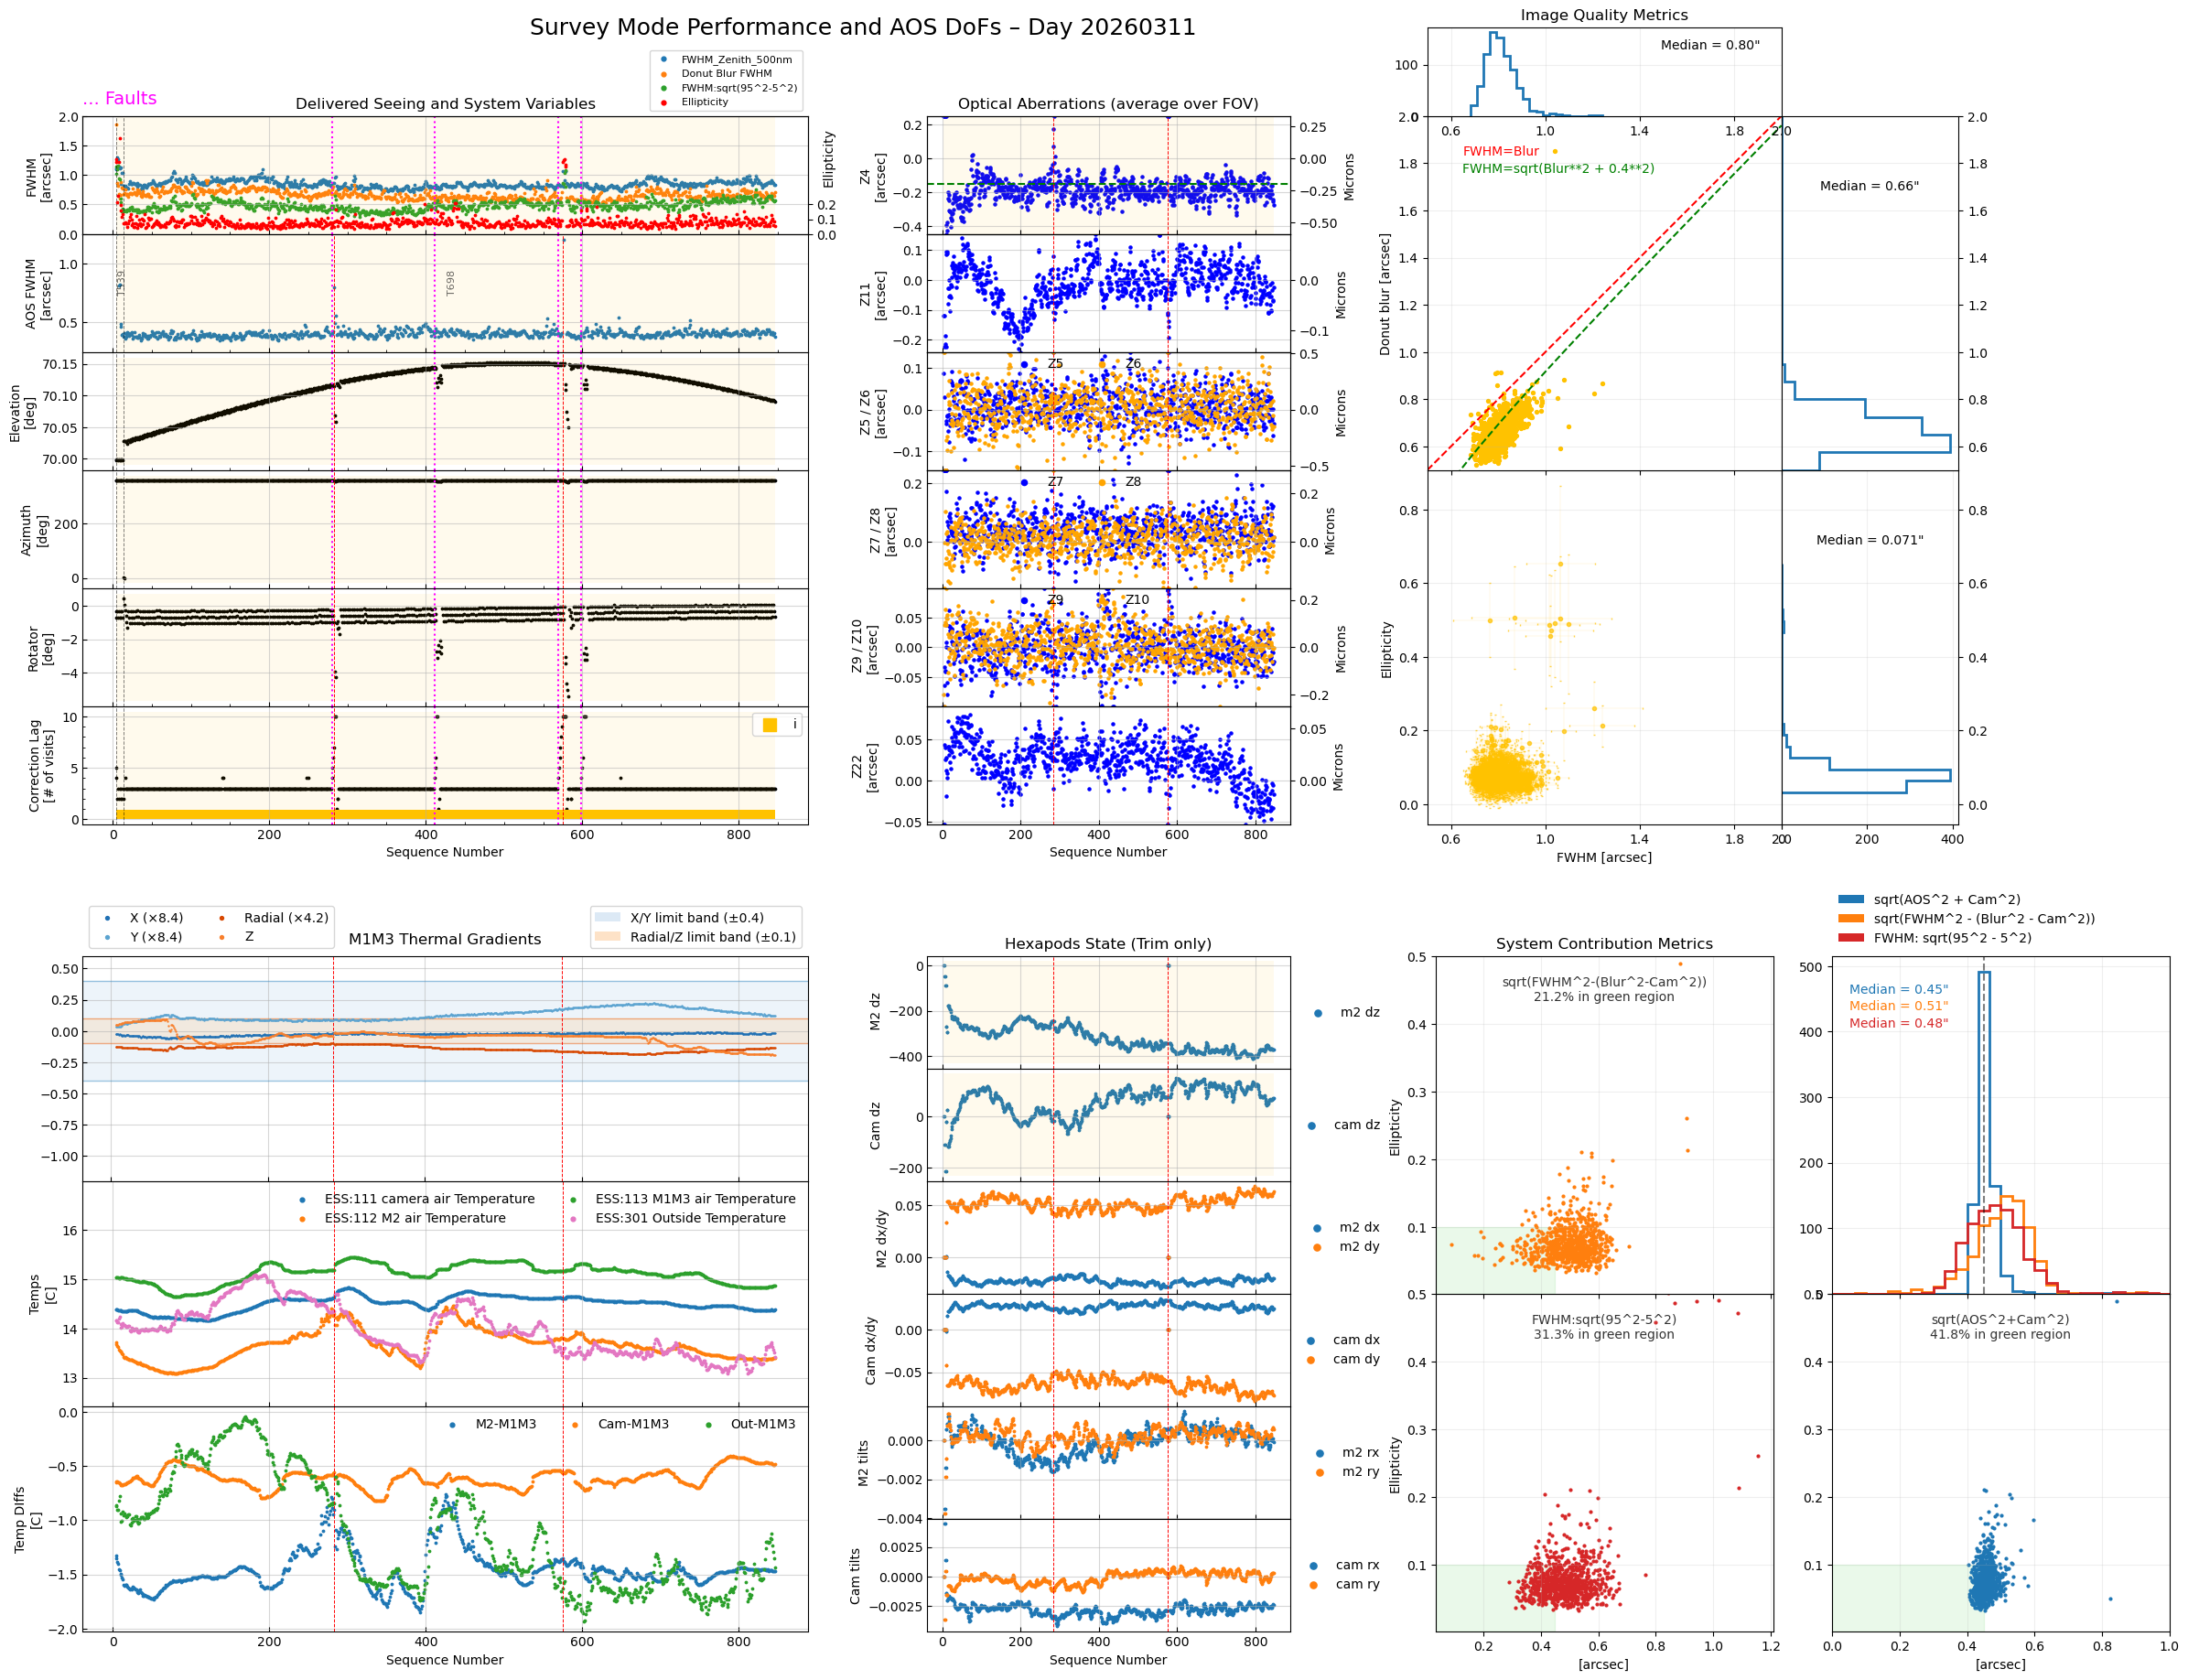

In [12]:
plot_standard_report(result, day_obs, save_png=True)

Saved nightly_report_detailed_20260311.png


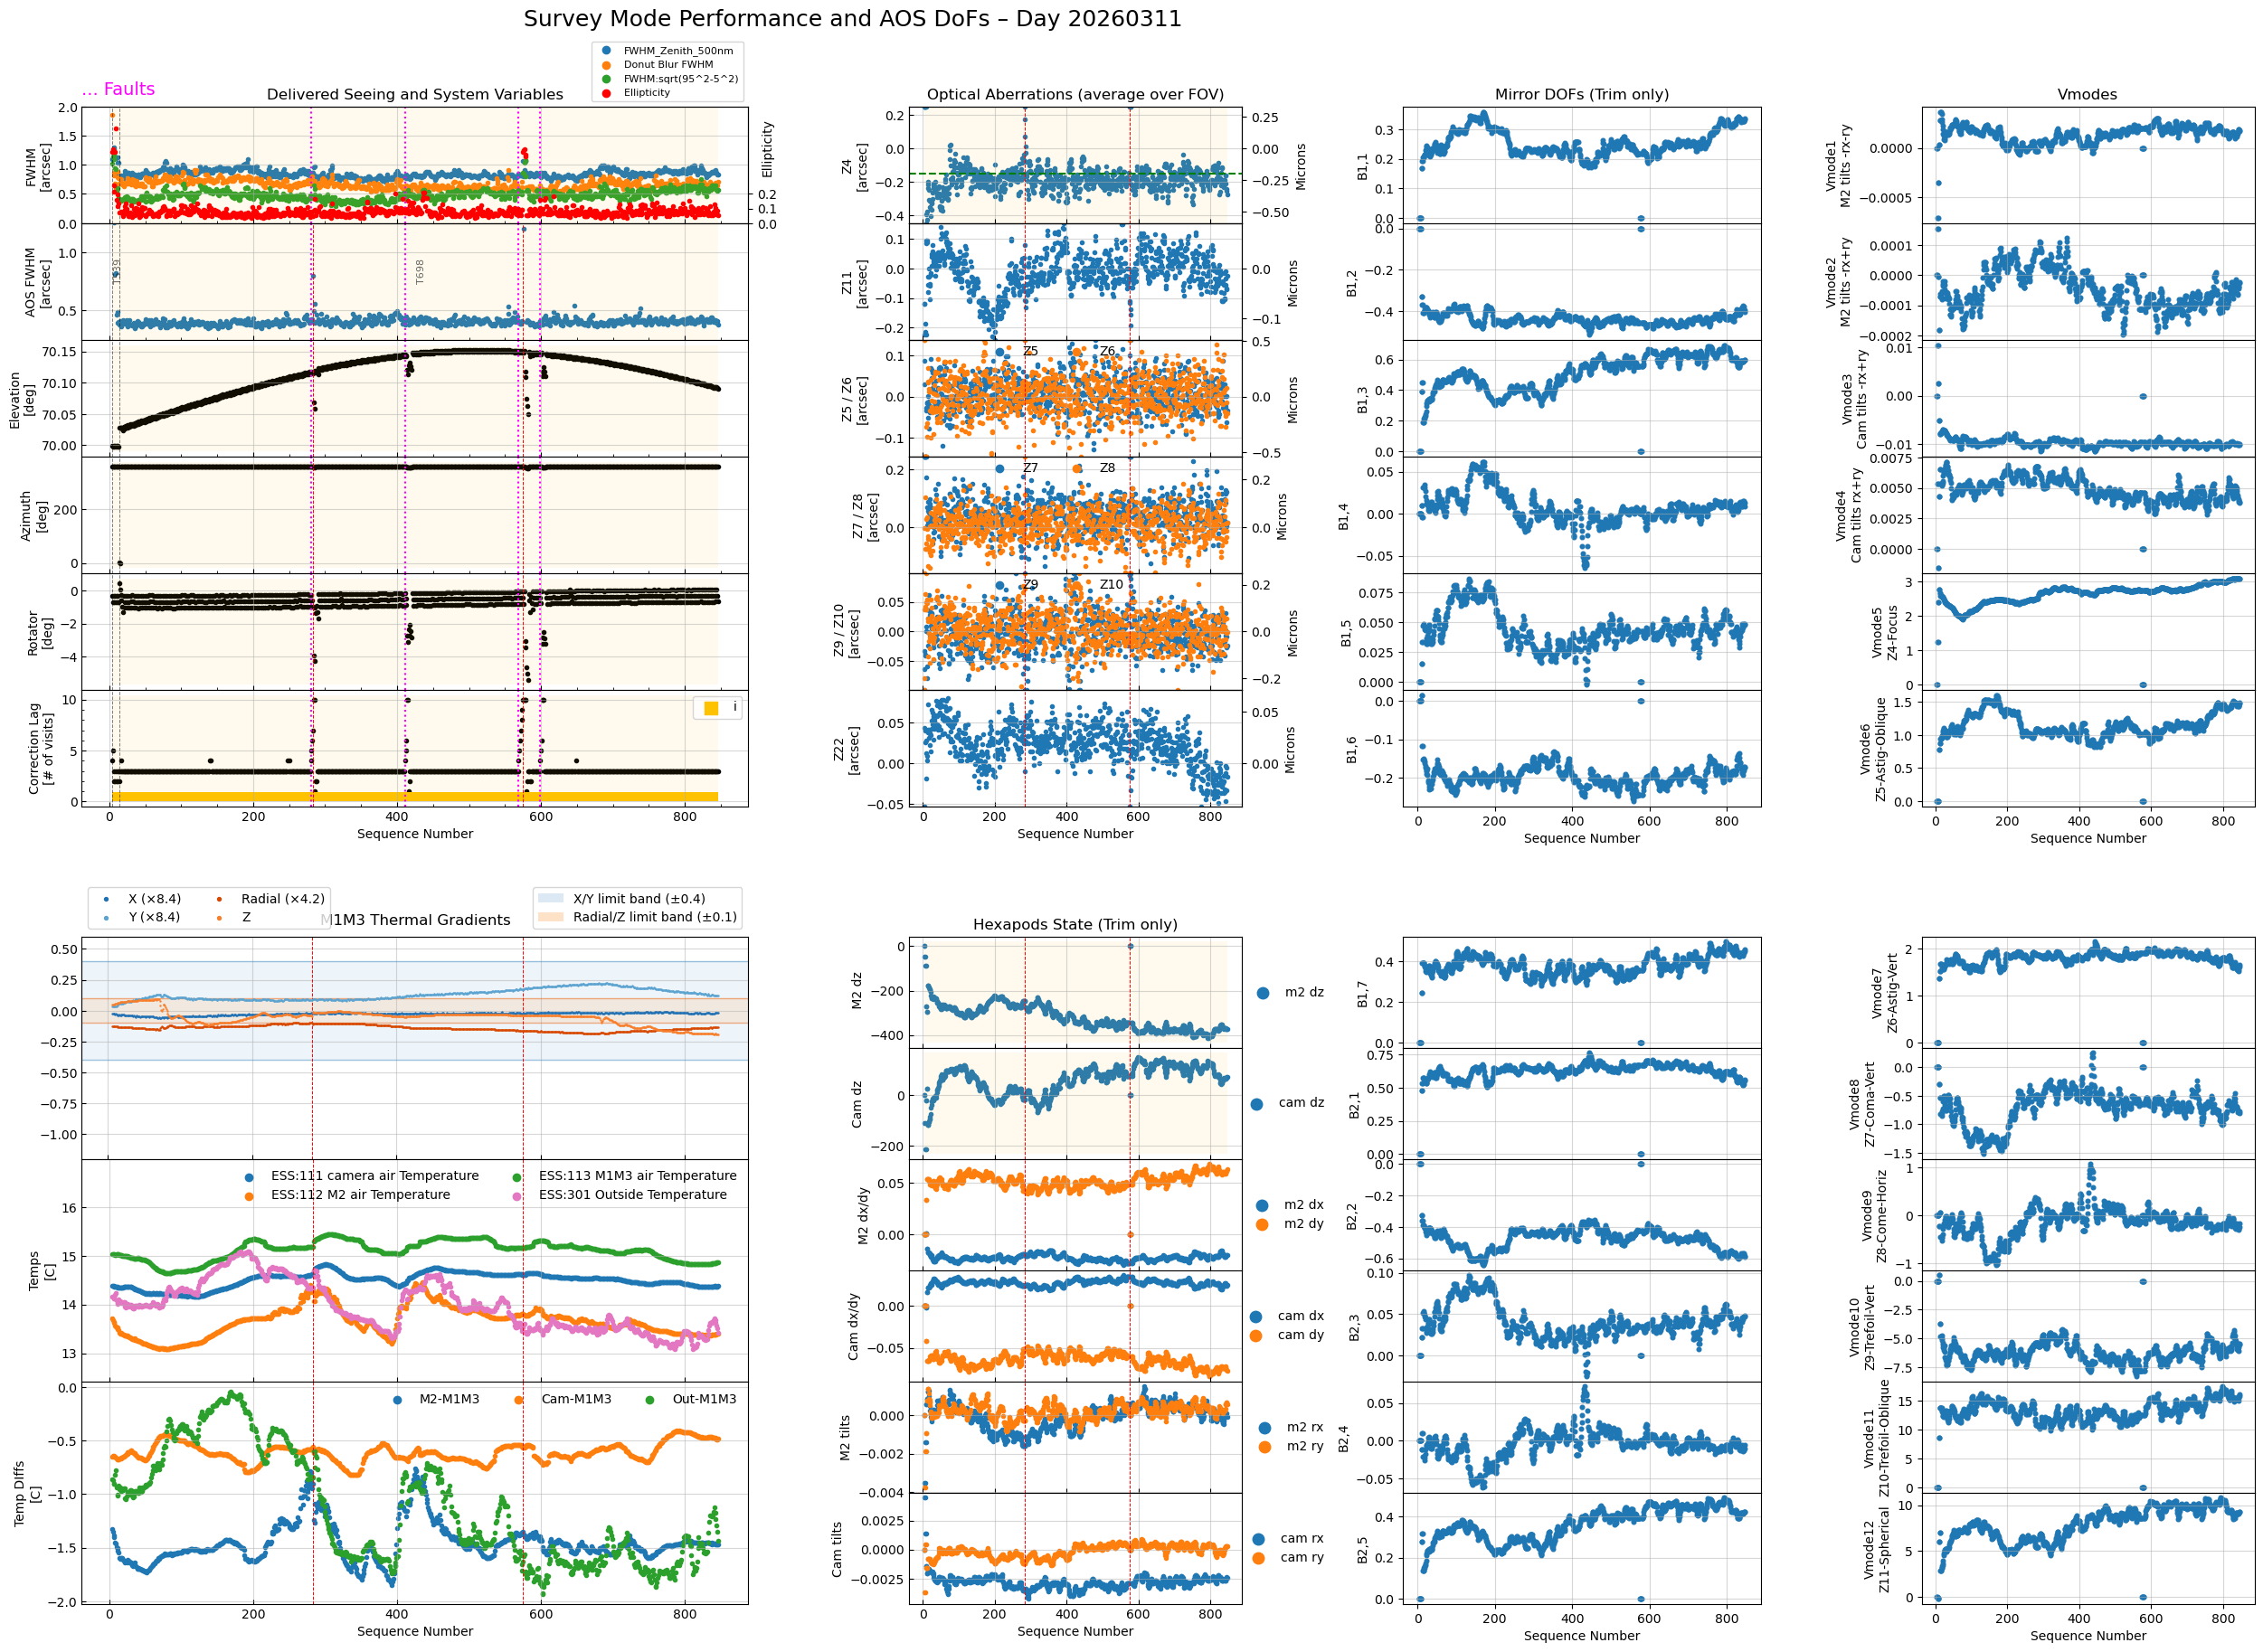

In [13]:
plot_detailed_report(result, day_obs, save_png=True)

<a id="Multi-Night"></a>
## Multi-Night

### Multi-night example

Uncomment and edit the cell below to run over multiple nights.

In [14]:
# day_obs_list = [20260115, 20260116, 20260117]
# for d in day_obs_list:
#     tbl = await build_nightly_table(d)
#     tbl.to_parquet(f"nightly_aos_table_{d}.parquet")
#     print(f"Done {d}: {len(tbl)} rows")